---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>

<br>

---

<br>

## **Identificação dos alunos**

A atividade deve ser realizada em **grupos de no máximo 5 alunos**. Preencha, abaixo, o nome e o RM de cada integrante do grupo. Caso o grupo tenha menos de cinco integrantes, mantenha sem preenchimento os campos não utilizados.


In [1]:
#@title Identificação
Nome_1 = "Pedro Rodrigues Almeida" #@param {type:"string"}
RM_1 = "564711" #@param {type:"string"}
Nome_2 = "Vitor Carvalho Alexandre" #@param {type:"string"}
RM_2 = "561732" #@param {type:"string"}
Nome_3 = "Alexandre Martins Lucas" #@param {type:"string"}
RM_3 = "561732" #@param {type:"string"}
Nome_4 = "Gabriel Barbosa da Silva" #@param {type:"string"}
RM_4 = "570133" #@param {type:"string"}
Nome_5 = "" #@param {type:"string"}
RM_5 = "" #@param {type:"string"}

<br>

---

<br>

# **CheckPoint05**

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

## **Instruções**

- Leia cada enunciado com atenção.
- Observe a pontuação indicada em cada questão. A atividade vale **10 pontos** no total.
- O grupo deve escolher **um único problema** que possa ser tratado como classificação ou regressão e utilizar a mesma base em toda a atividade.
- A base pode ser pública, institucional autorizada ou coletada pelo grupo. A fonte, a licença ou a forma de obtenção devem ser documentadas.
- O problema deve produzir uma representação tabular de atributos e variável-alvo. Não utilize dados pessoais ou sensíveis sem autorização e justificativa acadêmica adequada.
- Sempre que necessário, registre o raciocínio antes da implementação em Python.
- Quando o item pedir interpretação, responda com base nos resultados obtidos, não apenas com definições genéricas.
- Responda os exercícios nos espaços indicados. Caso seja necessário, adicione células para complementar a resposta.
- Indique de forma organizada a solução dos exercícios.
- Preocupe-se em fazer um código Python limpo, documentado e reprodutível. Esse aspecto será avaliado ao longo de toda a atividade.
- O conjunto de **teste deve permanecer isolado** durante seleção de variáveis, comparação de modelos e tuning. Ele só poderá ser utilizado no Exercício 7.
- O envio da atividade deve incluir o notebook `.ipynb`, o link do repositório GitHub e o link da aplicação Streamlit.
- Cada grupo deverá realizar uma **apresentação oral da solução, com duração máxima de 10 minutos**, sintetizando o problema, as principais decisões metodológicas, a comparação entre os modelos, o modelo final e a demonstração da aplicação.
- Execute o notebook do início ao fim antes do envio. Ele não deve conter erros durante a execução.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Entregáveis obrigatórios:</strong> notebook final, repositório GitHub reproduzível, aplicação Streamlit funcional e **apresentação oral da solução com duração máxima de 10 minutos**. O repositório deve conter, no mínimo, README com instruções de execução, arquivo de dependências, código da aplicação e os arquivos necessários para reproduzir o treinamento ou carregar o modelo final.
</div>


In [2]:
# imports e configuração visual do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager

fontes_preferidas = [
    "Latin Modern Roman",
    "CMU Serif",
    "Georgia",
    "DejaVu Serif",
]

fonte_serif = "DejaVu Serif"
for fonte in fontes_preferidas:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Fonte serifada selecionada para os gráficos: {fonte_serif}")

Fonte serifada selecionada para os gráficos: Latin Modern Roman


In [3]:
# bibliotecas de modelagem e configuração de reprodutibilidade
import sys
import time
import json
import warnings
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")  # silencia avisos de importação (ex.: barra de progresso do tqdm)

import joblib
import optuna
import sklearn
import xgboost
import lightgbm
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict,
    GridSearchCV, learning_curve,
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, recall_score,
    precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
)

# módulo do projeto compartilhado com a aplicação Streamlit
RAIZ = Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src.preparacao import (
    carregar_base, limpar_dados, codificar_alvo, criar_pipeline, criar_preprocessador,
    VARIAVEIS_NUMERICAS, VARIAVEIS_CATEGORICAS, VARIAVEIS_MODELO, ALVO, IDENTIFICADOR,
)
from src.inferencia import carregar_artefato, prever

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
N_JOBS = -1          # paralelismo nos folds (CV / Grid Search / Optuna)
MODELO_N_JOBS = 1    # cada estimador usa 1 núcleo para evitar disputa de CPU

CORES = {"Random Forest": "#3b528b", "XGBoost": "#21918c", "LightGBM": "#5ec962"}

print(f"scikit-learn {sklearn.__version__} | xgboost {xgboost.__version__} | "
      f"lightgbm {lightgbm.__version__} | optuna {optuna.__version__}")

scikit-learn 1.9.1 | xgboost 3.4.1 | lightgbm 4.7.0 | optuna 5.0.0


<br>

---

<br>

## **Notação utilizada na atividade**

Considere a base de dados como

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n},
$$

em que $\mathbf{x}_i$ representa as variáveis preditoras da observação $i$ e $y_i$ representa a variável-alvo. Ao organizar os dados, utilize a notação

$$
\mathbf{X} \quad \text{para a matriz de atributos},
\qquad
\mathbf{y} \quad \text{para o vetor da variável-alvo}.
$$

A separação deve produzir

$$
\mathcal{D}_{\mathrm{treino}}
\quad \text{e} \quad
\mathcal{D}_{\mathrm{teste}},
$$

sendo $\mathcal{D}_{\mathrm{teste}}$ mantido fora de todo o processo de seleção e tuning. Os três modelos serão indicados por

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

As previsões serão representadas por $\hat{\mathbf{y}}$. Para hiperparâmetros, utilize $\boldsymbol{\theta}$ e registre os melhores valores encontrados por cada estratégia de busca.

<br>

---

<br>

## **Exercícios propostos**

A atividade foi organizada como um fluxo completo de desenvolvimento de um projeto de machine learning. Os sete exercícios devem ser respondidos em sequência, pois as decisões tomadas nas etapas iniciais serão utilizadas nas etapas seguintes.

<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.


**Resposta do aluno — Exercício 1**

**1. Contexto e problema.** Em operadoras de telecomunicações, adquirir um cliente novo custa várias vezes mais do que reter um cliente atual, e o cancelamento (*churn*) costuma ser decidido com pouco aviso. A pergunta preditiva é:

> *Dado o perfil contratual, os serviços contratados e o histórico de cobrança de um cliente, qual é a probabilidade de ele cancelar o serviço?*

Uma solução supervisionada é adequada porque a base contém o desfecho observado (cancelou ou não) para milhares de clientes; o modelo aprende o padrão entre as características e o desfecho e pode ser aplicado a clientes ativos para priorizar ações de retenção (ofertas, migração de contrato, contato do suporte). Os três algoritmos de árvores são apropriados porque a base é tabular, mistura variáveis numéricas e categóricas e tem relações não lineares e interações (ex.: contrato × permanência).

**2. Variável-alvo.** $y = \texttt{Churn}$, codificada como $y=1$ se o cliente cancelou no último mês e $y=0$ caso contrário. Trata-se de **classificação binária**. A saída do modelo é uma probabilidade $\hat{p}=P(y=1\mid\mathbf{x})$ — um *escore de risco de cancelamento* — e a previsão $\hat{y}=\mathbb{1}[\hat{p}\geq t]$ indica se o cliente deve entrar na lista de retenção, com o limiar $t$ definido na validação (Exercício 6).

**3. Base de dados.** *Telco Customer Churn* (IBM Sample Data Sets), base pública publicada pela IBM para fins educacionais e disponível no repositório [IBM/telco-customer-churn-on-icp4d](https://github.com/IBM/telco-customer-churn-on-icp4d) (licença Apache 2.0). Obtida por download direto do CSV; uma cópia está versionada em `data/`. A base tem **7.043 linhas e 21 colunas**; a **unidade observacional é o cliente** (um `customerID` por linha). As variáveis cobrem demografia (gênero, idoso, parceiro, dependentes), relacionamento (`tenure`, tipo de contrato, forma de pagamento, fatura digital), serviços contratados (telefone, internet e seis serviços adicionais) e cobrança (`MonthlyCharges`, `TotalCharges`). Os dados são fictícios/anonimizados, sem informações pessoais identificáveis.

**4. Critério de sucesso.** A métrica principal comum aos três algoritmos é a **ROC-AUC**. Justificativa: (i) as classes são desbalanceadas (≈26,5% de churn), e a acurácia premiaria um modelo trivial que prevê "não cancela" para todos (≈73,5%); (ii) o uso de negócio é **ordenar clientes por risco** para uma campanha de capacidade limitada, e a AUC mede exatamente a qualidade dessa ordenação, independentemente do limiar; (iii) é contínua e estável entre folds, o que favorece o tuning. Métricas auxiliares (PR-AUC, F1, recall, precision e acurácia) são detalhadas no Exercício 3.

In [4]:
# Resposta do aluno - exercício 1
# Carregamento da base (cópia local em data/; se ausente, download da fonte pública da IBM)
df_bruto = carregar_base("data/Telco-Customer-Churn.csv")

print(f"Dimensões iniciais: {df_bruto.shape[0]} linhas x {df_bruto.shape[1]} colunas")
print(f"Unidade observacional: 1 linha = 1 cliente ({df_bruto[IDENTIFICADOR].nunique()} IDs únicos)")
display(df_bruto.head())

Dimensões iniciais: 7043 linhas x 21 colunas
Unidade observacional: 1 linha = 1 cliente (7043 IDs únicos)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


**Dicionário de dados.** Descrição das 21 colunas originais, com tipo lógico e papel no projeto.

In [5]:
descricoes = {
    "customerID": ("Identificador do cliente", "identificador", "removida"),
    "gender": ("Gênero do titular (Female/Male)", "categórica", "preditora"),
    "SeniorCitizen": ("Cliente com 65 anos ou mais (0/1)", "binária", "preditora"),
    "Partner": ("Possui cônjuge/parceiro(a)", "binária", "preditora"),
    "Dependents": ("Possui dependentes", "binária", "preditora"),
    "tenure": ("Meses de permanência como cliente", "numérica", "preditora"),
    "PhoneService": ("Possui telefonia", "binária", "preditora"),
    "MultipleLines": ("Possui múltiplas linhas", "categórica", "preditora"),
    "InternetService": ("Tipo de internet (DSL, Fiber optic, No)", "categórica", "preditora"),
    "OnlineSecurity": ("Serviço de segurança online", "categórica", "preditora"),
    "OnlineBackup": ("Serviço de backup online", "categórica", "preditora"),
    "DeviceProtection": ("Proteção de dispositivo", "categórica", "preditora"),
    "TechSupport": ("Suporte técnico", "categórica", "preditora"),
    "StreamingTV": ("Streaming de TV", "categórica", "preditora"),
    "StreamingMovies": ("Streaming de filmes", "categórica", "preditora"),
    "Contract": ("Tipo de contrato (mensal, 1 ano, 2 anos)", "categórica", "preditora"),
    "PaperlessBilling": ("Fatura digital", "binária", "preditora"),
    "PaymentMethod": ("Forma de pagamento", "categórica", "preditora"),
    "MonthlyCharges": ("Valor cobrado no mês (US$)", "numérica", "preditora"),
    "TotalCharges": ("Valor total faturado até o momento (US$)", "numérica (lida como texto)", "preditora"),
    "Churn": ("Cliente cancelou no último mês (Yes/No)", "binária", "alvo"),
}
dicionario = pd.DataFrame(
    [(c, *descricoes[c], str(df_bruto[c].dtype), df_bruto[c].nunique()) for c in df_bruto.columns],
    columns=["variável", "descrição", "tipo lógico", "papel", "dtype original", "nº valores distintos"],
)
display(dicionario)

,variável,descrição,tipo lógico,papel,dtype original,nº valores distintos
0,customerID,Identificador do cliente,identificador,removida,str,7043
1,gender,Gênero do titular (Female/Male),categórica,preditora,str,2
2,SeniorCitizen,Cliente com 65 anos ou mais (0/1),binária,preditora,int64,2
3,Partner,Possui cônjuge/parceiro(a),binária,preditora,str,2
4,Dependents,Possui dependentes,binária,preditora,str,2
5,tenure,Meses de permanência como cliente,numérica,preditora,int64,73
6,PhoneService,Possui telefonia,binária,preditora,str,2
7,MultipleLines,Possui múltiplas linhas,categórica,preditora,str,3
8,InternetService,"Tipo de internet (DSL, Fiber optic, No)",categórica,preditora,str,3
9,OnlineSecurity,Serviço de segurança online,categórica,preditora,str,3


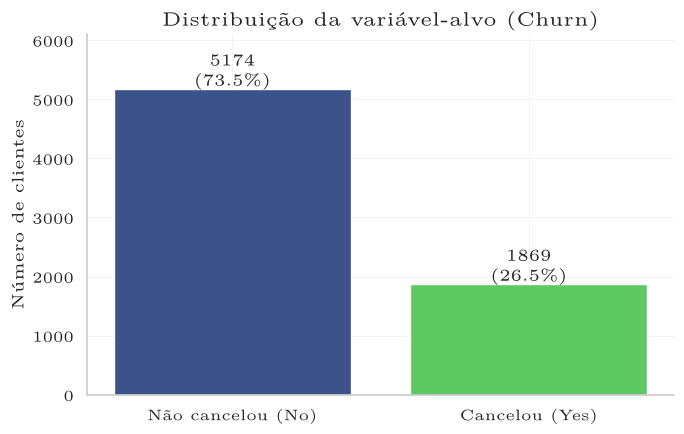

Taxa de churn: 26.54% -> classes desbalanceadas (~1:2,8)


In [6]:
# distribuição da variável-alvo
contagem = df_bruto[ALVO].value_counts()
proporcao = df_bruto[ALVO].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(["Não cancelou (No)", "Cancelou (Yes)"], contagem.loc[["No", "Yes"]],
                color=["#3b528b", "#5ec962"])
for b, p in zip(barras, proporcao.loc[["No", "Yes"]]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 60,
            f"{int(b.get_height())}\n({p:.1%})", ha="center")
ax.set_title("Distribuição da variável-alvo (Churn)")
ax.set_ylabel("Número de clientes")
ax.set_ylim(0, contagem.max() * 1.18)
plt.tight_layout()
plt.show()

print(f"Taxa de churn: {proporcao['Yes']:.2%} -> classes desbalanceadas (~1:2,8)")

<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>


**Resposta do aluno — Exercício 2**

O exercício está organizado em quatro blocos: (2.1) diagnóstico, (2.2) tratamento, (2.3) análise exploratória e (2.4) base final. As conclusões de cada bloco estão nas células de texto logo após os respectivos resultados.

#### 2.1 Diagnóstico de qualidade

In [7]:
# Resposta do aluno - exercício 2
# 2.1 Diagnóstico: tipos, ausências, duplicidades, categorias e valores impossíveis
diagnostico = pd.DataFrame({
    "dtype": df_bruto.dtypes.astype(str),
    "nulos (NaN)": df_bruto.isna().sum(),
    "textos vazios": [(df_bruto[c].astype(str).str.strip() == "").sum() for c in df_bruto.columns],
    "valores distintos": df_bruto.nunique(),
})
display(diagnostico)

print("Linhas duplicadas (todas as colunas):", df_bruto.duplicated().sum())
print("customerID duplicados:", df_bruto[IDENTIFICADOR].duplicated().sum())
print("Linhas duplicadas ignorando customerID:", df_bruto.drop(columns=IDENTIFICADOR).duplicated().sum())

,dtype,nulos (NaN),textos vazios,valores distintos
customerID,str,0,0,7043
gender,str,0,0,2
SeniorCitizen,int64,0,0,2
Partner,str,0,0,2
Dependents,str,0,0,2
tenure,int64,0,0,73
PhoneService,str,0,0,2
MultipleLines,str,0,0,3
InternetService,str,0,0,3
OnlineSecurity,str,0,0,3


Linhas duplicadas (todas as colunas): 0
customerID duplicados: 0
Linhas duplicadas ignorando customerID: 22


TotalCharges não numérico: 11 linhas


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.5500,,No
753,3115-CZMZD,0,20.2500,,No
936,5709-LVOEQ,0,80.8500,,No
1082,4367-NUYAO,0,25.7500,,No
1340,1371-DWPAZ,0,56.0500,,No
3331,7644-OMVMY,0,19.8500,,No
3826,3213-VVOLG,0,25.3500,,No
4380,2520-SGTTA,0,20.0000,,No
5218,2923-ARZLG,0,19.7000,,No
6670,4075-WKNIU,0,73.3500,,No


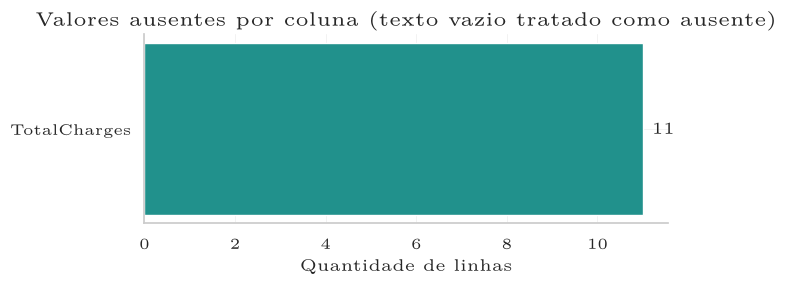

In [8]:
# TotalCharges está como texto: quais valores não convertem para número?
total_num = pd.to_numeric(df_bruto["TotalCharges"], errors="coerce")
mascara_invalida = total_num.isna()
print(f"TotalCharges não numérico: {mascara_invalida.sum()} linhas")
display(df_bruto.loc[mascara_invalida, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

# gráfico de valores ausentes após a conversão numérica
ausentes = df_bruto.replace(r"^\s*$", np.nan, regex=True).isna().sum()
ausentes = ausentes[ausentes > 0]
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(ausentes.index, ausentes.values, color="#21918c")
ax.set_title("Valores ausentes por coluna (texto vazio tratado como ausente)")
ax.set_xlabel("Quantidade de linhas")
for i, v in enumerate(ausentes.values):
    ax.text(v + 0.2, i, str(v), va="center")
plt.tight_layout()
plt.show()

In [9]:
# categorias: valores únicos de cada variável textual
categoricas_brutas = [c for c in df_bruto.columns
                      if c not in (IDENTIFICADOR, "TotalCharges", "tenure", "MonthlyCharges", "SeniorCitizen")]
for c in categoricas_brutas:
    print(f"{c:18s} -> {sorted(df_bruto[c].astype(str).unique())}")

gender             -> ['Female', 'Male']
Partner            -> ['No', 'Yes']
Dependents         -> ['No', 'Yes']
PhoneService       -> ['No', 'Yes']
MultipleLines      -> ['No', 'No phone service', 'Yes']
InternetService    -> ['DSL', 'Fiber optic', 'No']
OnlineSecurity     -> ['No', 'No internet service', 'Yes']
OnlineBackup       -> ['No', 'No internet service', 'Yes']
DeviceProtection   -> ['No', 'No internet service', 'Yes']
TechSupport        -> ['No', 'No internet service', 'Yes']
StreamingTV        -> ['No', 'No internet service', 'Yes']
StreamingMovies    -> ['No', 'No internet service', 'Yes']
Contract           -> ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   -> ['No', 'Yes']
PaymentMethod      -> ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn              -> ['No', 'Yes']


In [10]:
# valores impossíveis e consistência entre colunas numéricas
display(df_bruto[["tenure", "MonthlyCharges"]].assign(TotalCharges=total_num).describe().T)

checagens = {
    "tenure < 0": (df_bruto["tenure"] < 0).sum(),
    "tenure > 72 (limite do produto)": (df_bruto["tenure"] > 72).sum(),
    "MonthlyCharges <= 0": (df_bruto["MonthlyCharges"] <= 0).sum(),
    "TotalCharges < 0": (total_num < 0).sum(),
    "TotalCharges < MonthlyCharges com tenure >= 1": ((total_num < df_bruto["MonthlyCharges"] * 0.5)
                                                       & (df_bruto["tenure"] >= 1)).sum(),
    "SeniorCitizen fora de {0,1}": (~df_bruto["SeniorCitizen"].isin([0, 1])).sum(),
}
display(pd.Series(checagens, name="ocorrências").to_frame())

# TotalCharges deve ser aproximadamente tenure x MonthlyCharges
razao = total_num / (df_bruto["tenure"] * df_bruto["MonthlyCharges"])
print("Razão TotalCharges / (tenure x MonthlyCharges): "
      f"mediana = {razao.median():.3f}, P1 = {razao.quantile(.01):.3f}, P99 = {razao.quantile(.99):.3f}")

,count,mean,std,min,25%,50%,75%,max
tenure,"7,043.0000",32.3711,24.5595,0.0000,9.0000,29.0000,55.0000,72.0000
MonthlyCharges,"7,043.0000",64.7617,30.0900,18.2500,35.5000,70.3500,89.8500,118.7500
TotalCharges,"7,032.0000","2,283.3004","2,266.7714",18.8000,401.4500,"1,397.4750","3,794.7375","8,684.8000"


,ocorrências
tenure < 0,0
tenure > 72 (limite do produto),0
MonthlyCharges <= 0,0
TotalCharges < 0,0
TotalCharges < MonthlyCharges com tenure >= 1,0
"SeniorCitizen fora de {0,1}",0


Razão TotalCharges / (tenure x MonthlyCharges): mediana = 1.000, P1 = 0.855, P99 = 1.159


**Achados do diagnóstico (2.1).**

- **Tipos:** 18 colunas textuais, 2 inteiras (`SeniorCitizen`, `tenure`) e 1 real (`MonthlyCharges`). `TotalCharges` deveria ser numérica, mas foi lida como texto.
- **Ausências:** nenhum `NaN` explícito; porém `TotalCharges` tem **11 textos em branco** (ausências "disfarçadas"). Os 11 casos têm `tenure = 0` e `Churn = No`: são clientes recém-contratados que ainda não receberam a primeira fatura — ausência **estrutural**, e não aleatória.
- **Duplicidades:** nenhuma linha nem `customerID` duplicado. Há 22 linhas idênticas quando o ID é ignorado; como os IDs diferem, são clientes distintos com o mesmo perfil.
- **Categorias inconsistentes:** não há erros de digitação ou variações de caixa, mas há **categorias redundantes**: "No internet service" (6 colunas) repete a informação de `InternetService = No`, e "No phone service" repete `PhoneService = No`. `SeniorCitizen` usa 0/1 enquanto as demais binárias usam Yes/No.
- **Valores impossíveis:** nenhum valor negativo, `tenure` dentro de 0–72 meses e `SeniorCitizen` em {0, 1}. A razão $\texttt{TotalCharges}/(\texttt{tenure}\times\texttt{MonthlyCharges})$ tem mediana 1,000 e 98% dos casos entre 0,86 e 1,16, confirmando a coerência entre as colunas de cobrança (as pequenas diferenças refletem reajustes ao longo do contrato).

#### 2.2 Tratamento dos dados

As regras abaixo estão implementadas em `src/preparacao.py::limpar_dados`, função importada **tanto por este notebook quanto pela aplicação Streamlit**. Todas são **determinísticas** — não aprendem nenhum parâmetro da amostra —, portanto podem ser aplicadas à base inteira antes da separação treino–teste sem gerar vazamento:

| Problema | Decisão | Justificativa |
|---|---|---|
| `TotalCharges` armazenada como texto | Conversão para `float` | É uma grandeza monetária contínua. |
| 11 valores em branco em `TotalCharges` | Preenchidos com **0** | Todos têm `tenure = 0`: são clientes que acabaram de entrar e ainda não receberam fatura. O valor correto pelo domínio é zero; não é uma imputação estatística. Remover essas linhas apagaria justamente o perfil de "cliente novo". |
| "No internet service" em 6 colunas de serviço | Recodificado para "No" | A informação já está em `InternetService == "No"`. Manter a terceira categoria criaria 6 colunas *dummy* idênticas entre si (colinearidade perfeita) sem informação nova. |
| "No phone service" em `MultipleLines` | Recodificado para "No" | Mesma lógica: redundante com `PhoneService == "No"`. |
| `SeniorCitizen` codificada como 0/1 e demais binárias como Yes/No | Convertida para "No"/"Yes" | Padroniza o formato; o One-Hot do pipeline gera uma única coluna para cada binária. |
| 22 linhas idênticas ignorando o `customerID` | **Mantidas** | Os IDs são distintos, logo são clientes diferentes com o mesmo perfil — algo plausível em uma base com poucas variáveis categóricas. Remover seria descartar observações legítimas. |

Nenhuma observação foi removida.

In [11]:
# 2.2 Aplicação do tratamento (mesma função usada pela aplicação Streamlit)
df = limpar_dados(df_bruto)

alteracoes = pd.DataFrame({
    "coluna": ["TotalCharges", "OnlineSecurity (e demais serviços de internet)", "MultipleLines", "SeniorCitizen"],
    "antes": [str(df_bruto["TotalCharges"].dtype) + " com 11 brancos",
              str(sorted(df_bruto["OnlineSecurity"].unique())),
              str(sorted(df_bruto["MultipleLines"].unique())),
              str(sorted(df_bruto["SeniorCitizen"].unique()))],
    "depois": [str(df["TotalCharges"].dtype) + f" com {df['TotalCharges'].isna().sum()} ausentes",
               str(sorted(df["OnlineSecurity"].unique())),
               str(sorted(df["MultipleLines"].unique())),
               str(sorted(df["SeniorCitizen"].unique()))],
})
display(alteracoes)
display(df.loc[mascara_invalida, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].head(3))

,coluna,antes,depois
0,TotalCharges,str com 11 brancos,float64 com 0 ausentes
1,OnlineSecurity (e demais serviços de internet),"['No', 'No internet service', 'Yes']","['No', 'Yes']"
2,MultipleLines,"['No', 'No phone service', 'Yes']","['No', 'Yes']"
3,SeniorCitizen,"[np.int64(0), np.int64(1)]","['No', 'Yes']"


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.5500,0.0000
753,3115-CZMZD,0,20.2500,0.0000
936,5709-LVOEQ,0,80.8500,0.0000


#### 2.3 Análise exploratória

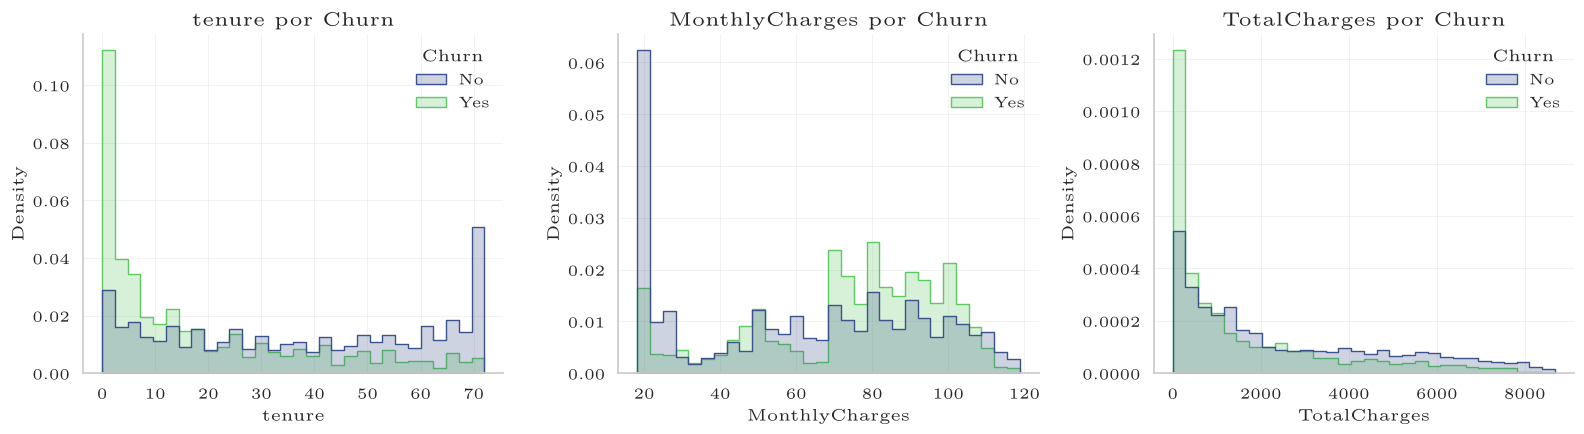

,tenure,MonthlyCharges,TotalCharges
Churn (mediana),,,
No,38.0000,64.4250,"1,679.5250"
Yes,10.0000,79.6500,703.5500


In [12]:
# Gráfico 1 - distribuição das variáveis numéricas por classe do alvo
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, VARIAVEIS_NUMERICAS):
    sns.histplot(data=df, x=col, hue=ALVO, hue_order=["No", "Yes"], bins=30, stat="density",
                 common_norm=False, element="step", palette=["#3b528b", "#5ec962"], ax=ax)
    ax.set_title(f"{col} por Churn")
plt.tight_layout()
plt.show()

display(df.groupby(ALVO)[VARIAVEIS_NUMERICAS].median().rename_axis("Churn (mediana)"))

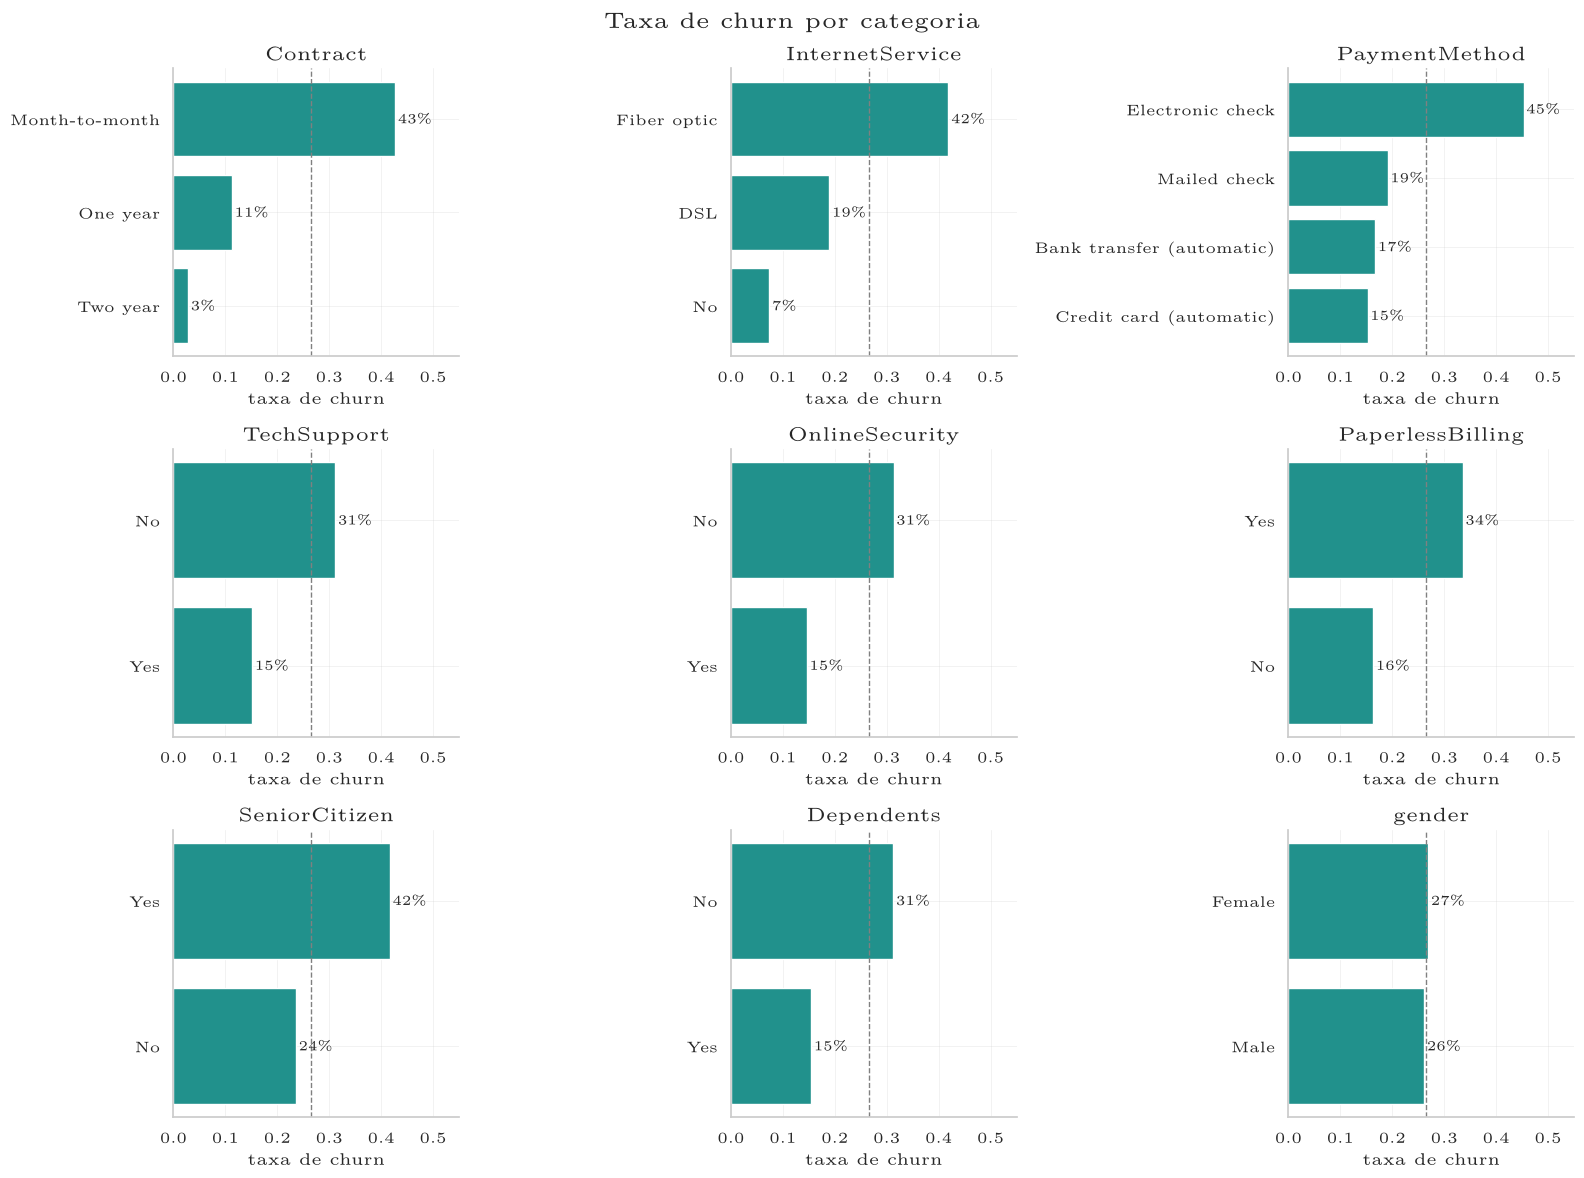

In [13]:
# Gráfico 2 - taxa de churn por variável categórica (linha tracejada = taxa global)
taxa_global = (df[ALVO] == "Yes").mean()
cat_plot = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
            "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Dependents", "gender"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), cat_plot):
    taxa = df.groupby(col)[ALVO].apply(lambda s: (s == "Yes").mean()).sort_values()
    ax.barh(taxa.index.astype(str), taxa.values, color="#21918c")
    ax.axvline(taxa_global, ls="--", color="gray", lw=1)
    for i, v in enumerate(taxa.values):
        ax.text(v + 0.005, i, f"{v:.0%}", va="center", fontsize=10)
    ax.set_title(col)
    ax.set_xlim(0, 0.55)
    ax.set_xlabel("taxa de churn")
plt.suptitle("Taxa de churn por categoria", fontsize=16)
plt.tight_layout()
plt.show()

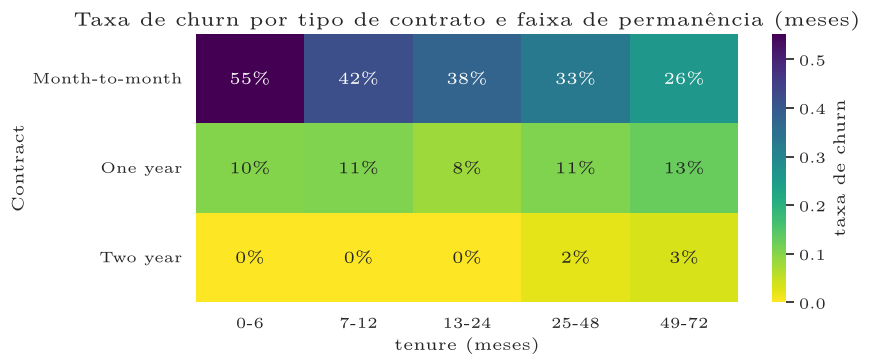

In [14]:
# Gráfico 3 - churn por faixa de permanência e tipo de contrato
df_eda = df.assign(
    churn_bin=(df[ALVO] == "Yes").astype(int),
    faixa_tenure=pd.cut(df["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                        labels=["0-6", "7-12", "13-24", "25-48", "49-72"]),
)
pivo = df_eda.pivot_table(index="Contract", columns="faixa_tenure", values="churn_bin",
                          aggfunc="mean", observed=False)
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.heatmap(pivo, annot=True, fmt=".0%", cmap="viridis_r", cbar_kws={"label": "taxa de churn"}, ax=ax)
ax.set_title("Taxa de churn por tipo de contrato e faixa de permanência (meses)")
ax.set_xlabel("tenure (meses)")
plt.tight_layout()
plt.show()

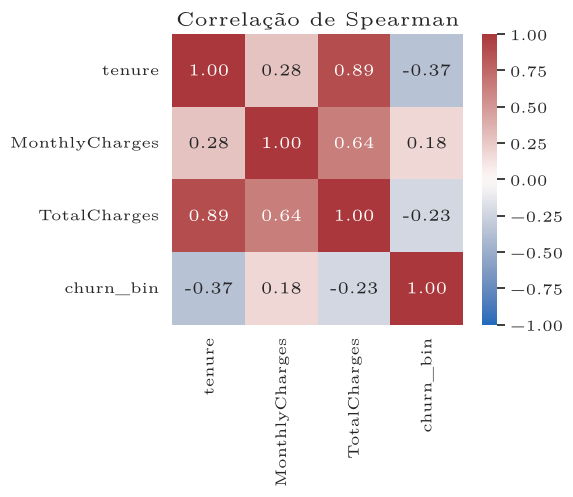

In [15]:
# Gráfico 4 - correlação de Spearman entre numéricas e o alvo
corr = df_eda[VARIAVEIS_NUMERICAS + ["churn_bin"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlação de Spearman")
plt.tight_layout()
plt.show()

**Interpretação da análise exploratória (2.3).**

1. **Variáveis numéricas (Gráfico 1).** Quem cancela tem permanência muito menor (mediana de 10 meses contra 38) e mensalidade mais alta (US\$ 79,65 contra US\$ 64,43). A distribuição de `tenure` dos churners concentra-se nos primeiros meses; a dos que ficam é bimodal, com um pico em 72 meses (clientes fidelizados). `TotalCharges` é menor nos churners porque é, essencialmente, permanência × mensalidade.
2. **Variáveis categóricas (Gráfico 2).** O **tipo de contrato** é o fator mais discriminante: 43% de churn no mensal, 11% no anual e 3% no bienal. Também elevam o risco: internet por **fibra óptica** (42%), pagamento por **boleto eletrônico** (*electronic check*, 45%), **ausência de suporte técnico e de segurança online** (31% contra 15%), fatura digital (34%) e clientes idosos (42%). Ter dependentes reduz o risco. **Gênero praticamente não diferencia** (27% vs. 26%).
3. **Interação contrato × permanência (Gráfico 3).** O risco é máximo em clientes de contrato mensal nos 6 primeiros meses (55%) e cai com o tempo (26% após 4 anos), enquanto os contratos de 1 e 2 anos permanecem baixos em qualquer faixa. Essa **interação não linear** é exatamente o tipo de padrão que modelos de árvore capturam sem engenharia manual de atributos.
4. **Correlações (Gráfico 4).** `tenure` e `TotalCharges` têm correlação de Spearman 0,89 (redundância parcial, sem prejuízo para árvores); a associação monotônica com o churn é negativa para `tenure` (−0,37) e positiva para `MonthlyCharges` (+0,18).

**Implicações para a modelagem:** espera-se que contrato, permanência, tipo de internet e forma de pagamento dominem a importância das variáveis; o desbalanceamento (26,5%) justifica ROC-AUC e PR-AUC em vez de acurácia; e as interações observadas favorecem métodos baseados em árvores.

#### 2.4 Base final

In [16]:
# 2.4 Verificação da base tratada
print(f"Dimensões após o tratamento: {df.shape[0]} linhas x {df.shape[1]} colunas "
      f"(antes: {df_bruto.shape[0]} x {df_bruto.shape[1]})")
print("Valores ausentes restantes:", int(df.isna().sum().sum()))
print("Linhas duplicadas (todas as colunas):", df.duplicated().sum())
print("customerID duplicados:", df[IDENTIFICADOR].duplicated().sum())
display(df.dtypes.astype(str).value_counts().rename("nº de colunas").to_frame())

Dimensões após o tratamento: 7043 linhas x 21 colunas (antes: 7043 x 21)
Valores ausentes restantes: 0
Linhas duplicadas (todas as colunas): 0
customerID duplicados: 0


,nº de colunas
object,18
float64,2
int64,1


**Decisões que ainda ocorrerão dentro do pipeline** (`src/preparacao.py::criar_preprocessador`), ajustadas somente nos dados de treino de cada fold:

- **One-Hot Encoding** das 16 variáveis categóricas (`drop="if_binary"` para as binárias e `handle_unknown="ignore"` para categorias novas em produção). Embora o vocabulário seja fixo, o codificador é um transformador que aprende parâmetros, então fica no pipeline.
- **Imputação de salvaguarda** (mediana para numéricas, moda para categóricas). A base tratada não tem ausências, mas a aplicação Streamlit pode receber entradas incompletas; a estatística usada será a do treino.
- **Sem escalonamento**: Random Forest, XGBoost e LightGBM particionam por limiares e são invariantes a transformações monotônicas.
- **Sem balanceamento artificial** (SMOTE/undersampling): a métrica principal (ROC-AUC) é insensível à proporção de classes e o limiar de decisão será calibrado na validação cruzada (Exercício 6).

<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>


**Resposta do aluno — Exercício 3**

**3.1 Escolha das variáveis.** $\mathbf{y}$ = `Churn` (1 = cancelou). $\mathbf{X}$ contém as **19 variáveis restantes** (3 numéricas e 16 categóricas). Análise de vazamento (*data leakage*):

| Variável | Decisão | Motivo |
|---|---|---|
| `customerID` | **removida** | Identificador único; não tem relação causal com o churn e permitiria ao modelo memorizar registros. |
| `TotalCharges` | mantida | É o valor acumulado **até o momento da observação** — disponível para clientes ativos quando o modelo for usado. É quase $\texttt{tenure}\times\texttt{MonthlyCharges}$, mas a razão não é exatamente 1 (reajustes, mudanças de plano), então carrega informação residual. Alta correlação com `tenure` não prejudica modelos de árvore. |
| Demais variáveis | mantidas | Descrevem contrato, serviços e cobrança no momento da observação; nenhuma é posterior ao cancelamento nem codifica o alvo (não há, por exemplo, "data de cancelamento" ou "motivo do cancelamento"). |
| `gender` | mantida | Apresenta associação praticamente nula com o churn na EDA; foi mantida para **não remover variáveis com base no alvo antes da separação** (isso seria seleção orientada pelo alvo usando a base inteira). Os modelos podem ignorá-la. |

**3.2 Particionamento e validação.** Separação **80/20 estratificada** pelo alvo, com `random_state=42`: $\mathcal{D}_{\mathrm{treino}}$ com 5.634 clientes e $\mathcal{D}_{\mathrm{teste}}$ com 1.409. 80/20 deixa ≈374 casos de churn no teste — suficiente para uma estimativa estável da AUC — e mantém dados de treino abundantes. Dentro de $\mathcal{D}_{\mathrm{treino}}$ usa-se **`StratifiedKFold` com K = 5, `shuffle=True` e `random_state=42`**; o **mesmo objeto `cv`** é passado a todos os baselines, ao Grid Search, ao Optuna, à curva de aprendizado e às previsões out-of-fold, garantindo exatamente os mesmos folds para os três algoritmos. O pré-processamento está dentro do pipeline, logo é reajustado em cada fold.

**3.3 Métricas.**

| Métrica | Papel | Interpretação |
|---|---|---|
| **ROC-AUC** | **principal** (otimizada no tuning e usada na seleção) | Probabilidade de um cliente que cancela receber escore maior que um que fica. 0,5 = aleatório; 1 = ordenação perfeita. |
| PR-AUC (*average precision*) | auxiliar | Foca a classe minoritária; o valor de referência aleatório é a prevalência (≈0,265). Útil porque a ROC-AUC pode parecer otimista com desbalanceamento. |
| Recall | auxiliar | Fração dos clientes que cancelam e são capturados pela campanha — o erro mais caro é deixar de identificar quem vai sair. |
| Precision | auxiliar | Fração dos clientes sinalizados que realmente cancelariam — mede o desperdício de ofertas. |
| F1 | auxiliar | Equilíbrio entre recall e precision; usado para escolher o limiar de decisão na validação. |
| Acurácia | auxiliar (apenas referência) | Comparada com o baseline trivial de ≈0,735. |

Gap de sobreajuste: como a AUC é "maior é melhor", usa-se $\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}$.

In [17]:
# Resposta do aluno - exercício 3
# 3.1 Definição de X e y
variaveis_removidas = {
    "customerID": "identificador sem significado preditivo; poderia permitir memorização de registros",
}
X = df[VARIAVEIS_MODELO].copy()
y = codificar_alvo(df[ALVO])

print(f"X: {X.shape[0]} observações x {X.shape[1]} variáveis "
      f"({len(VARIAVEIS_NUMERICAS)} numéricas + {len(VARIAVEIS_CATEGORICAS)} categóricas)")
print(f"y: Churn (1 = cancelou) | prevalência = {y.mean():.2%}")
print("Variáveis removidas:", variaveis_removidas)

X: 7043 observações x 19 variáveis (3 numéricas + 16 categóricas)
y: Churn (1 = cancelou) | prevalência = 26.54%
Variáveis removidas: {'customerID': 'identificador sem significado preditivo; poderia permitir memorização de registros'}


In [18]:
# 3.2 Separação treino-teste estratificada (80/20) e validação cruzada
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# mesmos 5 folds estratificados para TODOS os modelos e estratégias de busca
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resumo_split = pd.DataFrame({
    "conjunto": ["D_treino", "D_teste"],
    "linhas": [len(X_treino), len(X_teste)],
    "proporção": [len(X_treino) / len(X), len(X_teste) / len(X)],
    "taxa de churn": [y_treino.mean(), y_teste.mean()],
})
display(resumo_split)

folds = [{"fold": k + 1, "treino": len(tr), "validação": len(va),
          "churn validação": y_treino.iloc[va].mean()}
         for k, (tr, va) in enumerate(cv.split(X_treino, y_treino))]
display(pd.DataFrame(folds))

,conjunto,linhas,proporção,taxa de churn
0,D_treino,5634,0.7999,0.2654
1,D_teste,1409,0.2001,0.2654


,fold,treino,validação,churn validação
0,1,4507,1127,0.2653
1,2,4507,1127,0.2653
2,3,4507,1127,0.2653
3,4,4507,1127,0.2653
4,5,4508,1126,0.2655


In [19]:
# 3.3 Métricas: principal (ROC-AUC) e auxiliares
METRICA_PRINCIPAL = "roc_auc"
SCORING = {
    "roc_auc": "roc_auc",                 # principal: capacidade de ordenar clientes por risco
    "average_precision": "average_precision",  # PR-AUC: foco na classe minoritária
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "accuracy": "accuracy",
}
print("Métrica principal:", METRICA_PRINCIPAL)
print("Referência de acurácia trivial (sempre 'não cancela'):", f"{1 - y_treino.mean():.3f}")
print("Referência de PR-AUC aleatória (= prevalência):", f"{y_treino.mean():.3f}")

Métrica principal: roc_auc
Referência de acurácia trivial (sempre 'não cancela'): 0.735
Referência de PR-AUC aleatória (= prevalência): 0.265


<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.


**Resposta do aluno — Exercício 4**

Os três baselines usam **os hiperparâmetros padrão de cada biblioteca** (fixando apenas `random_state`, `n_jobs` e, no LightGBM, `verbose`). Todos passam pelo **mesmo pipeline** de pré-processamento, pelos **mesmos 5 folds** e pelas **mesmas métricas**. A função `avaliar_cv` abaixo é reutilizada nos Exercícios 4, 5 e 6 para que todos os números sejam produzidos do mesmo jeito.

- **Métrica no treino** = média da ROC-AUC nas partições de treino de cada fold (`return_train_score=True`).
- **Média e desvio-padrão da CV** = ROC-AUC nas 5 partições de validação.
- **Tempo** = tempo médio de ajuste por fold e tempo total da validação cruzada.

In [20]:
# Resposta do aluno - exercício 4
def avaliar_cv(pipeline, nome, X_=None, y_=None):
    """Avalia um pipeline com o protocolo comum (mesmos folds e métricas)."""
    X_ = X_treino if X_ is None else X_
    y_ = y_treino if y_ is None else y_
    inicio = time.perf_counter()
    res = cross_validate(pipeline, X_, y_, cv=cv, scoring=SCORING,
                         return_train_score=True, n_jobs=N_JOBS)
    total = time.perf_counter() - inicio
    linha = {
        "configuração": nome,
        "AUC treino": res["train_roc_auc"].mean(),
        "AUC CV média": res["test_roc_auc"].mean(),
        "AUC CV desvio": res["test_roc_auc"].std(),
        "gap (treino - CV)": res["train_roc_auc"].mean() - res["test_roc_auc"].mean(),
        "PR-AUC CV": res["test_average_precision"].mean(),
        "F1 CV (limiar 0,5)": res["test_f1"].mean(),
        "recall CV (limiar 0,5)": res["test_recall"].mean(),
        "acurácia CV": res["test_accuracy"].mean(),
        "tempo ajuste/fold (s)": res["fit_time"].mean(),
        "tempo total CV (s)": total,
    }
    return linha, res["test_roc_auc"]


modelos_baseline = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS,
                             eval_metric="logloss", tree_method="hist"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS, verbose=-1),
}

# hiperparâmetros registrados de cada baseline
params_relevantes = {
    "Random Forest": ["n_estimators", "max_depth", "min_samples_leaf", "max_features"],
    "XGBoost": ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree"],
    "LightGBM": ["n_estimators", "num_leaves", "learning_rate", "min_child_samples", "max_depth"],
}
for nome, modelo in modelos_baseline.items():
    p = modelo.get_params()
    print(f"{nome:14s}", {k: p.get(k) for k in params_relevantes[nome]})
print("Obs.: valores None no XGBoost indicam o padrão interno da biblioteca "
      "(n_estimators=100, max_depth=6, learning_rate=0,3, subsample=1, colsample_bytree=1).")

Random Forest  {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
XGBoost        {'n_estimators': None, 'max_depth': None, 'learning_rate': None, 'subsample': None, 'colsample_bytree': None}
LightGBM       {'n_estimators': 100, 'num_leaves': 31, 'learning_rate': 0.1, 'min_child_samples': 20, 'max_depth': -1}
Obs.: valores None no XGBoost indicam o padrão interno da biblioteca (n_estimators=100, max_depth=6, learning_rate=0,3, subsample=1, colsample_bytree=1).


In [21]:
# treinamento e avaliação dos três baselines sob o mesmo protocolo
linhas_baseline, scores_folds = [], {}
for nome, modelo in modelos_baseline.items():
    linha, folds_auc = avaliar_cv(criar_pipeline(modelo), f"{nome} | baseline")
    linha["modelo"] = nome
    linhas_baseline.append(linha)
    scores_folds[nome] = folds_auc

tabela_baseline = pd.DataFrame(linhas_baseline).set_index("configuração")
display(tabela_baseline[["AUC treino", "AUC CV média", "AUC CV desvio", "gap (treino - CV)",
                         "PR-AUC CV", "F1 CV (limiar 0,5)", "tempo ajuste/fold (s)", "tempo total CV (s)"]])

,AUC treino,AUC CV média,AUC CV desvio,gap (treino - CV),PR-AUC CV,"F1 CV (limiar 0,5)",tempo ajuste/fold (s),tempo total CV (s)
configuração,,,,,,,,
Random Forest | baseline,0.9999,0.8255,0.0100,0.1745,0.6175,0.5500,0.4796,3.4030
XGBoost | baseline,0.9895,0.8235,0.0064,0.1660,0.6269,0.5616,0.1012,0.6485
LightGBM | baseline,0.9626,0.8349,0.0081,0.1276,0.6428,0.5746,0.1044,0.8053


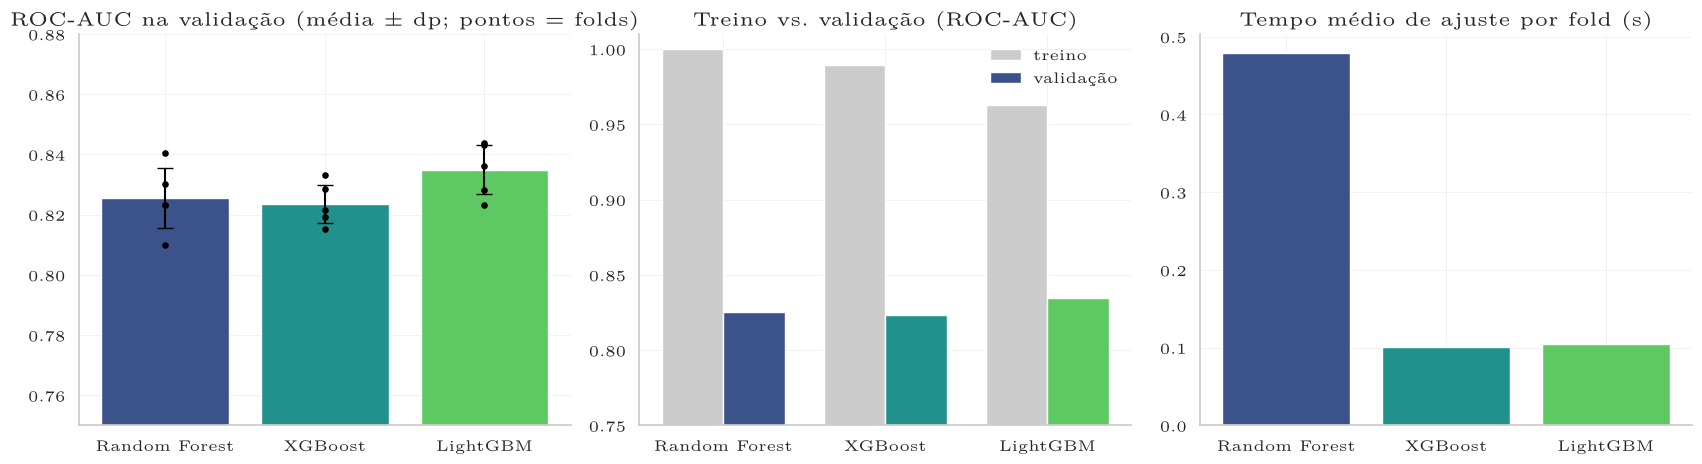

In [22]:
# visualizações da comparação inicial
nomes = list(modelos_baseline)
cores = [CORES[n] for n in nomes]
tb = tabela_baseline.set_index("modelo")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].bar(nomes, tb["AUC CV média"], yerr=tb["AUC CV desvio"], capsize=6, color=cores)
for i, n in enumerate(nomes):
    axes[0].scatter([i] * 5, scores_folds[n], color="black", s=14, zorder=3)
axes[0].set_ylim(0.75, 0.88)
axes[0].set_title("ROC-AUC na validação (média ± dp; pontos = folds)")

larg = 0.38
pos = np.arange(len(nomes))
axes[1].bar(pos - larg / 2, tb["AUC treino"], larg, label="treino", color="#cccccc")
axes[1].bar(pos + larg / 2, tb["AUC CV média"], larg, label="validação", color=cores)
axes[1].set_xticks(pos, nomes)
axes[1].set_ylim(0.75, 1.01)
axes[1].legend()
axes[1].set_title("Treino vs. validação (ROC-AUC)")

axes[2].bar(nomes, tb["tempo ajuste/fold (s)"], color=cores)
axes[2].set_title("Tempo médio de ajuste por fold (s)")

plt.tight_layout()
plt.show()

**Interpretação da comparação inicial.**

| Modelo | AUC treino | AUC CV (média ± dp) | Gap $\Delta_\uparrow$ |
|---|---|---|---|
| Random Forest | 0,9999 | 0,8255 ± 0,0100 | 0,175 |
| XGBoost | 0,9895 | 0,8235 ± 0,0064 | 0,166 |
| LightGBM | 0,9626 | **0,8349 ± 0,0081** | **0,128** |

- **Overfitting evidente nos três baselines.** Com os padrões das bibliotecas, as árvores crescem quase sem restrição: o Random Forest (`max_depth=None`, `min_samples_leaf=1`) praticamente decora o treino (AUC ≈ 1,0) e o XGBoost (`max_depth=6`, `learning_rate=0,3`) chega a 0,99. O gap de 0,13–0,17 pontos de AUC é muito maior que o desvio entre folds (≈0,01), portanto não é ruído.
- **LightGBM tem o melhor baseline** (≈ +0,01 de AUC sobre os outros dois, cerca de um desvio-padrão) e o menor gap. O crescimento por folhas com `min_child_samples=20` atua como uma regularização implícita, que faz diferença em uma base pequena (≈4,5 mil linhas por fold).
- **Não há sinal de underfitting:** todos estão bem acima do acaso (AUC 0,5) e a PR-AUC (0,62–0,64) é mais que o dobro da referência aleatória (0,265).
- **Custo:** XGBoost e LightGBM ajustam em ≈0,11 s por fold; o Random Forest leva ≈0,5 s (≈4,5× mais), pois constrói árvores profundas completas.
- **Conclusão para o tuning:** o problema dos baselines é **excesso de complexidade**, e não falta de capacidade. As grades devem, portanto, explorar profundidades menores, mais observações por folha e taxas de aprendizado menores.

<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>


**Resposta do aluno — Exercício 5**

**Protocolo.** Toda busca usa somente $\mathcal{D}_{\mathrm{treino}}$, o mesmo pipeline do Exercício 4, os mesmos 5 folds (`cv`) e a mesma métrica de otimização (ROC-AUC, maximizada). O conjunto de teste não é tocado.

**Grades do Grid Search** (cada grade testa complexidade, número de árvores e, nos boostings, taxa de aprendizado):

| Modelo | Hiperparâmetros | Combinações | Ajustes (×5 folds) |
|---|---|---|---|
| RF | `n_estimators` ∈ {200, 400}; `max_depth` ∈ {6, 10, None}; `min_samples_leaf` ∈ {1, 5, 15}; `max_features` ∈ {sqrt, 0,5} | 36 | 180 |
| XGB | `n_estimators` ∈ {200, 500}; `max_depth` ∈ {2, 3, 5}; `learning_rate` ∈ {0,01, 0,05, 0,1}; `subsample` ∈ {0,8, 1,0} | 36 | 180 |
| LGBM | `n_estimators` ∈ {200, 500}; `num_leaves` ∈ {7, 15, 31}; `learning_rate` ∈ {0,01, 0,05, 0,1}; `min_child_samples` ∈ {20, 60} | 36 | 180 |

**Espaços do Optuna** (amostrador TPE com `seed=42`, **40 trials por modelo**; contínuos em escala log quando cobrem ordens de grandeza):

| Modelo | Espaço de busca |
|---|---|
| RF | `n_estimators` 100–600 (passo 50); `max_depth` 3–20; `min_samples_leaf` 1–30; `max_features` ∈ {sqrt, log2, 0,3, 0,5, 0,7}; `min_samples_split` 2–20 |
| XGB | `n_estimators` 100–800 (passo 50); `learning_rate` 0,005–0,3 (log); `max_depth` 2–8; `subsample` 0,5–1; `colsample_bytree` 0,4–1; `min_child_weight` 1–20; `reg_lambda` 10⁻³–10 (log); `gamma` 0–5 |
| LGBM | `n_estimators` 100–800 (passo 50); `learning_rate` 0,005–0,3 (log); `num_leaves` 4–64; `min_child_samples` 5–100; `subsample` 0,5–1 (`subsample_freq=1`); `colsample_bytree` 0,4–1; `reg_lambda` 10⁻³–10 (log) |

A grade é pequena por construção (custo cresce multiplicativamente), enquanto o Optuna explora mais dimensões com um orçamento de avaliações semelhante (40 trials × 5 folds = 200 ajustes).

#### 5.1 Grid Search

In [23]:
# Resposta do aluno - exercício 5
# 5.1 Grid Search para os três modelos (prefixo "modelo__" acessa o estimador dentro do pipeline)
grades = {
    "Random Forest": {
        "modelo__n_estimators": [200, 400],
        "modelo__max_depth": [6, 10, None],
        "modelo__min_samples_leaf": [1, 5, 15],
        "modelo__max_features": ["sqrt", 0.5],
    },
    "XGBoost": {
        "modelo__n_estimators": [200, 500],
        "modelo__max_depth": [2, 3, 5],
        "modelo__learning_rate": [0.01, 0.05, 0.1],
        "modelo__subsample": [0.8, 1.0],
    },
    "LightGBM": {
        "modelo__n_estimators": [200, 500],
        "modelo__num_leaves": [7, 15, 31],
        "modelo__learning_rate": [0.01, 0.05, 0.1],
        "modelo__min_child_samples": [20, 60],
    },
}

resultados_grid, buscas_grid = [], {}
for nome, grade in grades.items():
    busca = GridSearchCV(criar_pipeline(modelos_baseline[nome]), grade, scoring=METRICA_PRINCIPAL,
                         cv=cv, n_jobs=N_JOBS, return_train_score=True, refit=False)
    inicio = time.perf_counter()
    busca.fit(X_treino, y_treino)
    duracao = time.perf_counter() - inicio
    buscas_grid[nome] = busca
    resultados_grid.append({
        "modelo": nome,
        "combinações": len(busca.cv_results_["params"]),
        "melhor AUC CV": busca.best_score_,
        "desvio (melhor)": busca.cv_results_["std_test_score"][busca.best_index_],
        "tempo de busca (s)": duracao,
        "melhores parâmetros": {k.replace("modelo__", ""): v for k, v in busca.best_params_.items()},
    })
    print(f"{nome:14s} AUC = {busca.best_score_:.4f} | {duracao:6.1f} s | {resultados_grid[-1]['melhores parâmetros']}")

tabela_grid = pd.DataFrame(resultados_grid).set_index("modelo")
display(tabela_grid)

Random Forest  AUC = 0.8482 |  130.0 s | {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'n_estimators': 200}


XGBoost        AUC = 0.8497 |   23.9 s | {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}


LightGBM       AUC = 0.8490 |   31.8 s | {'learning_rate': 0.01, 'min_child_samples': 60, 'n_estimators': 500, 'num_leaves': 7}


,combinações,melhor AUC CV,desvio (melhor),tempo de busca (s),melhores parâmetros
modelo,,,,,
Random Forest,36,0.8482,0.0102,129.9770,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
XGBoost,36,0.8497,0.0120,23.8667,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
LightGBM,36,0.8490,0.0119,31.7830,"{'learning_rate': 0.01, 'min_child_samples': 6..."


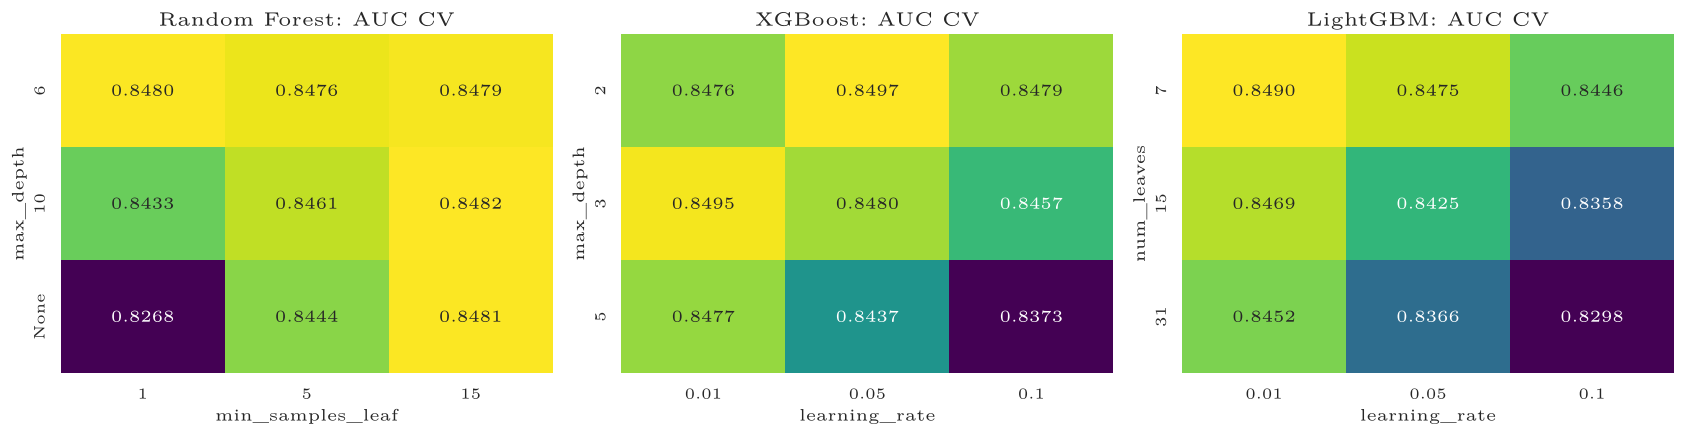

In [24]:
# Mapas de cv_results_: melhor AUC para cada par de hiperparâmetros (máximo sobre os demais)
pares = {
    "Random Forest": ("modelo__max_depth", "modelo__min_samples_leaf"),
    "XGBoost": ("modelo__max_depth", "modelo__learning_rate"),
    "LightGBM": ("modelo__num_leaves", "modelo__learning_rate"),
}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (nome, (p1, p2)) in zip(axes, pares.items()):
    res = pd.DataFrame(buscas_grid[nome].cv_results_)
    # None (sem limite de profundidade) vira texto para não ser descartado no pivot
    for p in (p1, p2):
        res[p] = res["param_" + p].apply(lambda v: "None" if v is None else v)
    mapa = res.pivot_table(index=p1, columns=p2, values="mean_test_score", aggfunc="max")
    ordenar = lambda idx: sorted(idx, key=lambda v: (isinstance(v, str), v if not isinstance(v, str) else 0))
    mapa = mapa.loc[ordenar(mapa.index), ordenar(mapa.columns)]
    sns.heatmap(mapa, annot=True, fmt=".4f", cmap="viridis", ax=ax, cbar=False)
    ax.set_title(f"{nome}: AUC CV")
    ax.set_ylabel(p1.replace("modelo__", ""))
    ax.set_xlabel(p2.replace("modelo__", ""))
plt.tight_layout()
plt.show()

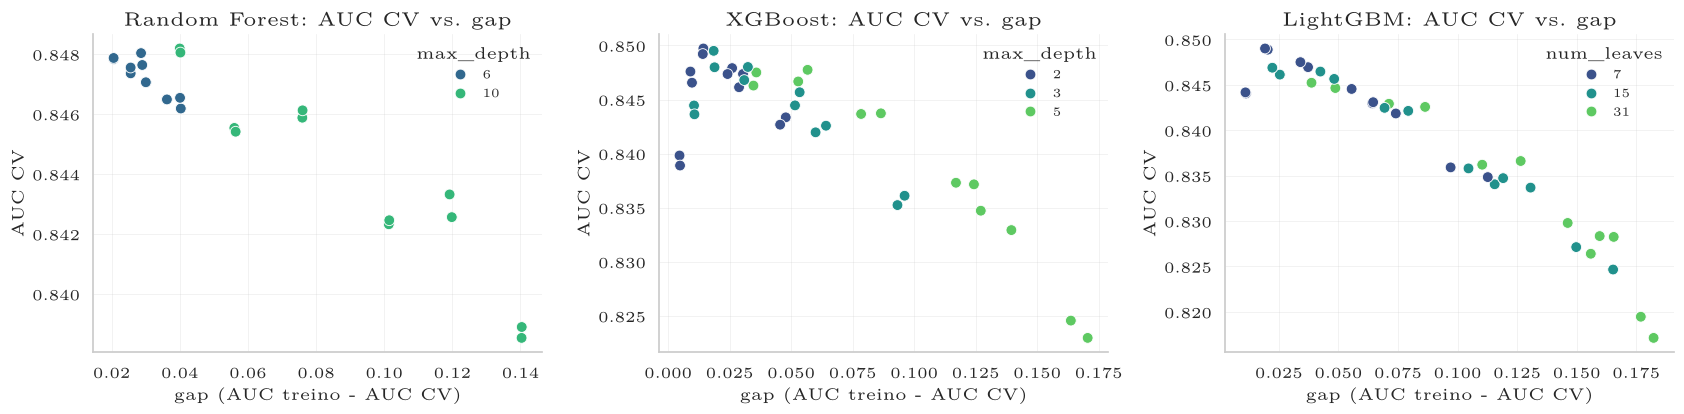

In [25]:
# Efeito do número de árvores e da complexidade no gap treino - validação (Grid Search)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, (nome, (p1, _)) in zip(axes, pares.items()):
    res = pd.DataFrame(buscas_grid[nome].cv_results_)
    res["gap"] = res["mean_train_score"] - res["mean_test_score"]
    res["complexidade"] = res["param_" + p1].astype(str)
    sns.scatterplot(data=res, x="gap", y="mean_test_score", hue="complexidade", ax=ax, s=60, palette="viridis")
    ax.set_title(f"{nome}: AUC CV vs. gap")
    ax.set_xlabel("gap (AUC treino - AUC CV)")
    ax.set_ylabel("AUC CV")
    ax.legend(title=p1.replace("modelo__", ""), fontsize=9)
plt.tight_layout()
plt.show()

#### 5.2 Optuna

In [26]:
# 5.2 Optuna: espaços de busca e função objetivo comum
N_TRIALS = 40

def espaco_rf(trial):
    return RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]),
        random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS,
    )

def espaco_xgb(trial):
    return XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 800, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS, eval_metric="logloss", tree_method="hist",
    )

def espaco_lgbm(trial):
    return LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 800, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        num_leaves=trial.suggest_int("num_leaves", 4, 64),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS, verbose=-1,
    )

espacos = {"Random Forest": espaco_rf, "XGBoost": espaco_xgb, "LightGBM": espaco_lgbm}


def criar_objetivo(construtor):
    """Objetivo: AUC média nos MESMOS 5 folds; desvio e gap são guardados para análise."""
    def objetivo(trial):
        res = cross_validate(criar_pipeline(construtor(trial)), X_treino, y_treino, cv=cv,
                             scoring=METRICA_PRINCIPAL, return_train_score=True, n_jobs=N_JOBS)
        trial.set_user_attr("cv_std", float(res["test_score"].std()))
        trial.set_user_attr("auc_treino", float(res["train_score"].mean()))
        return float(res["test_score"].mean())
    return objetivo


estudos, resultados_optuna = {}, []
for nome, construtor in espacos.items():
    estudo = optuna.create_study(direction="maximize", study_name=nome,
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    inicio = time.perf_counter()
    estudo.optimize(criar_objetivo(construtor), n_trials=N_TRIALS)
    duracao = time.perf_counter() - inicio
    estudos[nome] = estudo
    resultados_optuna.append({
        "modelo": nome,
        "trials": len(estudo.trials),
        "melhor AUC CV": estudo.best_value,
        "desvio (melhor)": estudo.best_trial.user_attrs["cv_std"],
        "tempo de busca (s)": duracao,
        "melhor trial": estudo.best_trial.number,
        "melhores parâmetros": {k: (round(v, 4) if isinstance(v, float) else v)
                                for k, v in estudo.best_params.items()},
    })
    print(f"{nome:14s} AUC = {estudo.best_value:.4f} | {duracao:6.1f} s | trial {estudo.best_trial.number}")
    print("    melhores parâmetros:", resultados_optuna[-1]["melhores parâmetros"])

tabela_optuna = pd.DataFrame(resultados_optuna).set_index("modelo")
display(tabela_optuna)

Random Forest  AUC = 0.8489 |  144.5 s | trial 26
    melhores parâmetros: {'n_estimators': 150, 'max_depth': 9, 'min_samples_leaf': 7, 'min_samples_split': 20, 'max_features': 'log2'}


XGBoost        AUC = 0.8499 |   30.8 s | trial 36
    melhores parâmetros: {'n_estimators': 450, 'learning_rate': 0.0138, 'max_depth': 5, 'subsample': 0.7717, 'colsample_bytree': 0.4397, 'min_child_weight': 15, 'reg_lambda': 0.7362, 'gamma': 2.8862}


LightGBM       AUC = 0.8499 |   48.6 s | trial 29
    melhores parâmetros: {'n_estimators': 300, 'learning_rate': 0.0067, 'num_leaves': 51, 'min_child_samples': 44, 'subsample': 0.6248, 'colsample_bytree': 0.4971, 'reg_lambda': 2.7397}


,trials,melhor AUC CV,desvio (melhor),tempo de busca (s),melhor trial,melhores parâmetros
modelo,,,,,,
Random Forest,40,0.8489,0.0102,144.5176,26,"{'n_estimators': 150, 'max_depth': 9, 'min_sam..."
XGBoost,40,0.8499,0.0122,30.8040,36,"{'n_estimators': 450, 'learning_rate': 0.0138,..."
LightGBM,40,0.8499,0.0119,48.5607,29,"{'n_estimators': 300, 'learning_rate': 0.0067,..."


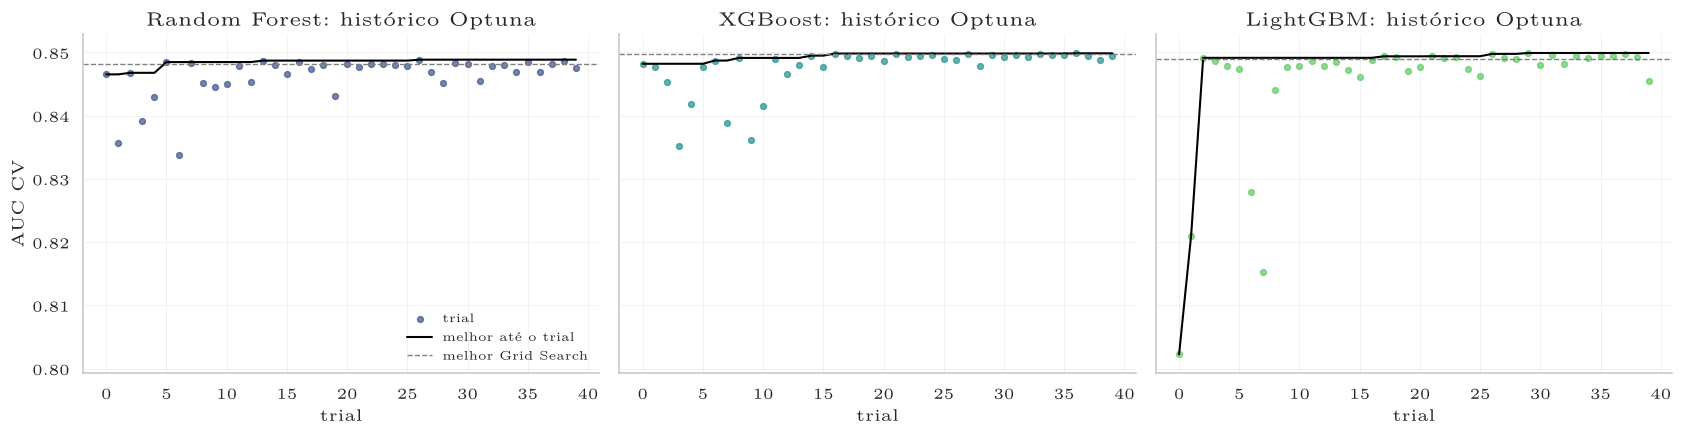

In [27]:
# Histórico de otimização do Optuna (pontos = trials; linha = melhor valor acumulado)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
for ax, (nome, estudo) in zip(axes, estudos.items()):
    valores = np.array([t.value for t in estudo.trials])
    ax.scatter(range(len(valores)), valores, s=18, color=CORES[nome], alpha=0.7, label="trial")
    ax.plot(np.maximum.accumulate(valores), color="black", lw=1.5, label="melhor até o trial")
    ax.axhline(tabela_grid.loc[nome, "melhor AUC CV"], ls="--", color="gray", lw=1, label="melhor Grid Search")
    ax.set_title(f"{nome}: histórico Optuna")
    ax.set_xlabel("trial")
axes[0].set_ylabel("AUC CV")
valores_todos = np.concatenate([[t.value for t in e.trials] for e in estudos.values()])
axes[0].set_ylim(valores_todos.min() - 0.003, valores_todos.max() + 0.003)
axes[0].legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

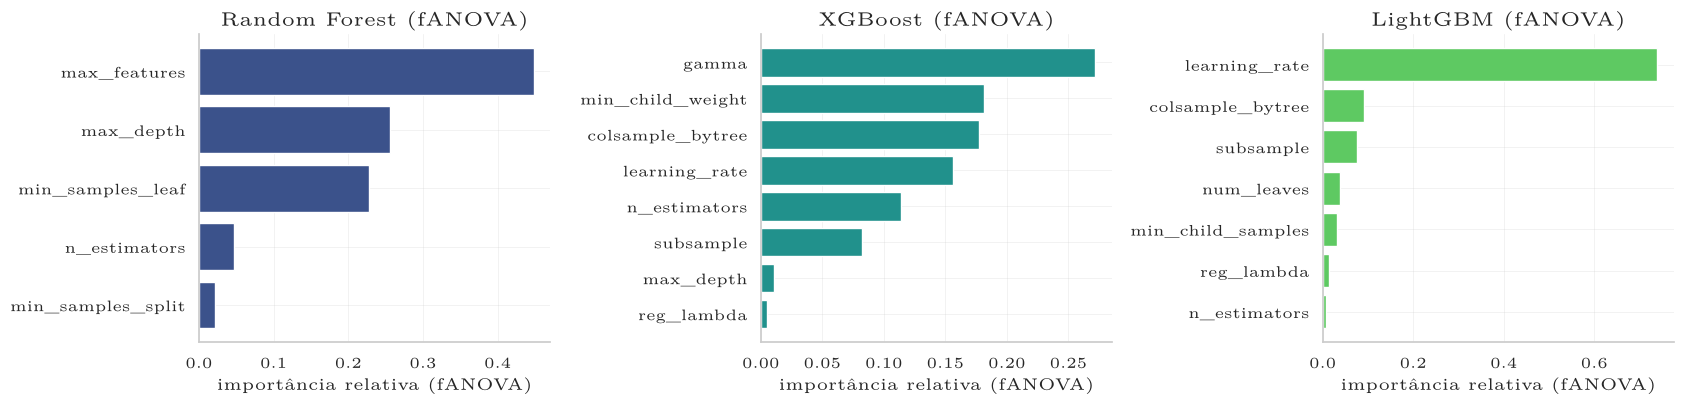

In [28]:
# Importância dos hiperparâmetros (fANOVA do Optuna)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for ax, (nome, estudo) in zip(axes, estudos.items()):
    imp = optuna.importance.get_param_importances(
        estudo, evaluator=optuna.importance.FanovaImportanceEvaluator(seed=RANDOM_STATE))
    imp = pd.Series(imp).sort_values()
    ax.barh(imp.index, imp.values, color=CORES[nome])
    ax.set_title(f"{nome} (fANOVA)")
    ax.set_xlabel("importância relativa (fANOVA)")
plt.tight_layout()
plt.show()

#### 5.3 Comparação entre Grid Search e Optuna

avaliações  melhor AUC CV  desvio no melhor  \
modelo        estratégia                                                 
Random Forest Grid Search          36         0.8482            0.0102   
              Optuna               40         0.8489            0.0102   
XGBoost       Grid Search          36         0.8497            0.0120   
              Optuna               40         0.8499            0.0122   
LightGBM      Grid Search          36         0.8490            0.0119   
              Optuna               40         0.8499            0.0119   

                           mediana das avaliações  tempo (s)  \
modelo        estratégia                                       
Random Forest Grid Search                  0.8459   129.9770   
              Optuna                       0.8477   144.5176   
XGBoost       Grid Search                  0.8445    23.8667   
              Optuna                       0.8491    30.8040   
LightGBM      Grid Search                  0.8423    31.7830   
              Optuna                       0.8486    48.5607   

                           tempo por avaliação (s)  
modelo        estratégia                            
Random Forest Grid Search                   3.6105  
              Optuna                        3.6129  
XGBoost       Grid Search                   0.6630  
              Optuna                        0.7701  
LightGBM      Grid Search                   0.8829  
              Optuna                        1.2140

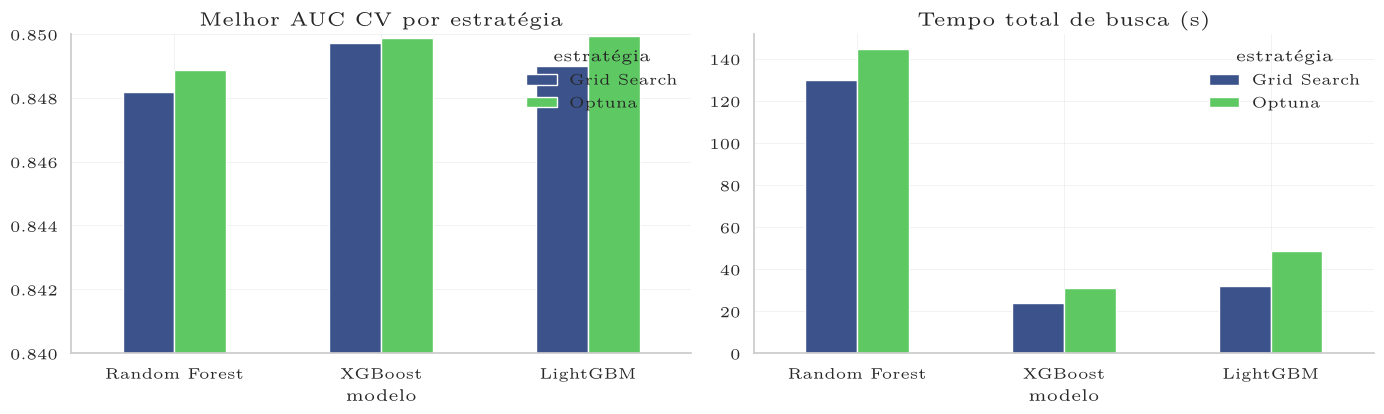

In [29]:
# 5.3 Comparação das estratégias: qualidade, estabilidade e custo
comparacao_busca = []
for nome in espacos:
    g, o = buscas_grid[nome], estudos[nome]
    valores_optuna = np.array([t.value for t in o.trials])
    comparacao_busca += [
        {"modelo": nome, "estratégia": "Grid Search",
         "avaliações": len(g.cv_results_["params"]),
         "melhor AUC CV": g.best_score_,
         "desvio no melhor": g.cv_results_["std_test_score"][g.best_index_],
         "mediana das avaliações": np.median(g.cv_results_["mean_test_score"]),
         "tempo (s)": tabela_grid.loc[nome, "tempo de busca (s)"]},
        {"modelo": nome, "estratégia": "Optuna",
         "avaliações": len(o.trials),
         "melhor AUC CV": o.best_value,
         "desvio no melhor": o.best_trial.user_attrs["cv_std"],
         "mediana das avaliações": np.median(valores_optuna),
         "tempo (s)": tabela_optuna.loc[nome, "tempo de busca (s)"]},
    ]
tabela_busca = pd.DataFrame(comparacao_busca)
tabela_busca["tempo por avaliação (s)"] = tabela_busca["tempo (s)"] / tabela_busca["avaliações"]
display(tabela_busca.set_index(["modelo", "estratégia"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
piv_auc = tabela_busca.pivot(index="modelo", columns="estratégia", values="melhor AUC CV").loc[list(espacos)]
piv_t = tabela_busca.pivot(index="modelo", columns="estratégia", values="tempo (s)").loc[list(espacos)]
piv_auc.plot.bar(ax=axes[0], color=["#3b528b", "#5ec962"], rot=0)
axes[0].set_ylim(0.84, 0.85)
axes[0].set_title("Melhor AUC CV por estratégia")
piv_t.plot.bar(ax=axes[1], color=["#3b528b", "#5ec962"], rot=0)
axes[1].set_title("Tempo total de busca (s)")
plt.tight_layout()
plt.show()

**Interpretação do tuning.**

**Resultados.** O tuning melhorou os três algoritmos em relação ao baseline (+0,015 a +0,026 de AUC), e todos convergiram para **≈0,848–0,850**:

| Modelo | Baseline | Grid Search | Optuna |
|---|---|---|---|
| Random Forest | 0,8255 | 0,8482 (`max_depth=10`, `min_samples_leaf=15`, 200 árvores) | 0,8489 |
| XGBoost | 0,8235 | 0,8497 (`max_depth=2`, `learning_rate=0,05`, 200 árvores, `subsample=0,8`) | 0,8499 |
| LightGBM | 0,8349 | 0,8490 (`num_leaves=7`, `learning_rate=0,01`, 500 árvores, `min_child_samples=60`) | 0,8499 |

As configurações vencedoras do Grid confirmam o diagnóstico do Exercício 4: **reduzem a complexidade** (árvores rasas no boosting, folhas com muitas observações no RF) e, nos boostings, usam taxa de aprendizado baixa. O Optuna chegou ao mesmo patamar por outro caminho: árvores mais profundas (XGBoost `max_depth=5`; LightGBM `num_leaves=51`) compensadas por taxa de aprendizado muito baixa (0,014 e 0,007), amostragem de colunas ≈0,45–0,50 e regularização explícita (XGBoost `gamma≈2,9`, `min_child_weight=15`; LightGBM `reg_lambda≈2,7`). No RF, o Optuna escolheu `max_depth=9`, `min_samples_leaf=7`, `max_features=log2` e 150 árvores. Regiões bem diferentes do espaço produzem praticamente a mesma AUC: há um **platô** de desempenho em ≈0,85. Os mapas do `cv_results_` mostram o mesmo padrão: no XGBoost e no LightGBM a AUC cai à medida que profundidade/folhas e taxa de aprendizado aumentam juntas (canto inferior direito ≈0,83–0,84); no RF, limitar `max_depth` ou aumentar `min_samples_leaf` é o que importa. O gráfico AUC × gap mostra que as configurações com maior gap tendem a ter AUC de validação menor.

**Grid Search × Optuna.**

- **Qualidade:** o Optuna encontrou o melhor valor nos três modelos, mas a vantagem é de **0,0002 a 0,0009** de AUC — uma ordem de grandeza menor que o desvio-padrão entre folds (≈0,012) e que o erro-padrão da média (≈0,005). Na prática, as duas estratégias empatam.
- **Comportamento da busca:** a mediana das avaliações do Optuna é bem maior (ex.: LightGBM 0,8486 contra 0,8423), porque o TPE concentra os trials nas regiões promissoras depois de ≈10–15 trials (veja o histórico), enquanto o Grid avalia uniformemente combinações ruins. O Optuna também explora **mais dimensões** (7–8 hiperparâmetros contra 4) com o mesmo orçamento; uma grade completa com 7 dimensões e 3 níveis exigiria 2.187 combinações.
- **Importância dos hiperparâmetros (fANOVA):** no LightGBM a `learning_rate` explica a maior parte da variação da AUC; no RF dominam `max_features`, `max_depth` e `min_samples_leaf`; no XGBoost a importância é distribuída (`gamma`, `min_child_weight`, `colsample_bytree`, `learning_rate`). O número de árvores importa pouco desde que a taxa de aprendizado seja ajustada.
- **Custo:** com orçamentos parecidos (36 vs. 40 avaliações × 5 folds), os tempos são da mesma ordem; nos boostings o Optuna foi um pouco mais caro por avaliação porque amostrou configurações com mais árvores (até 800), enquanto no RF o custo por avaliação foi praticamente igual. O Random Forest é de longe o algoritmo mais caro de ajustar (≈3,7 s por avaliação contra ≈0,7–1,2 s dos boostings).
- **Estabilidade e complexidade:** os desvios entre folds no melhor ponto são praticamente idênticos nas duas estratégias. Como as soluções do Optuna têm mais hiperparâmetros contínuos ajustados finamente (e, portanto, maior risco de se adaptar aos 5 folds específicos), um ganho de 0,0002 não justifica, por si só, preferi-las. A escolha final (Exercício 6) usa um critério que leva em conta incerteza e sobreajuste.

<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.


**Resposta do aluno — Exercício 6**

As nove configurações são reavaliadas pela mesma função `avaliar_cv` (mesmos folds), o que garante que treino, validação, desvio e tempo sejam medidos de forma idêntica. **Regra de seleção definida antes de olhar o resultado:**

1. calcula-se o erro-padrão da melhor configuração, $EP = \sigma_{CV}/\sqrt{K}$;
2. são candidatas todas as configurações com AUC CV $\geq$ melhor AUC $- EP$ (estatisticamente indistinguíveis da melhor com 5 folds);
3. entre as candidatas, escolhe-se a de **menor gap treino–validação** (menor indício de sobreajuste); em empate, a de menor custo.

Essa regra evita escolher um modelo apenas por diferenças na quarta casa decimal e privilegia a generalização.

#### 6.1 Tabela final e seleção

In [30]:
# Resposta do aluno - exercício 6
# 6.1 Nove configurações: baseline, melhor Grid Search e melhor Optuna para cada algoritmo
construtores = {"Random Forest": RandomForestClassifier, "XGBoost": XGBClassifier, "LightGBM": LGBMClassifier}
fixos = {
    "Random Forest": dict(random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS),
    "XGBoost": dict(random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS, eval_metric="logloss", tree_method="hist"),
    "LightGBM": dict(random_state=RANDOM_STATE, n_jobs=MODELO_N_JOBS, verbose=-1),
}

configuracoes = {}
for nome in construtores:
    configuracoes[f"{nome} | baseline"] = (nome, modelos_baseline[nome].get_params())
    configuracoes[f"{nome} | Grid Search"] = (
        nome, {**fixos[nome], **{k.replace("modelo__", ""): v for k, v in buscas_grid[nome].best_params_.items()}})
    extra = {"subsample_freq": 1} if nome == "LightGBM" else {}
    configuracoes[f"{nome} | Optuna"] = (nome, {**fixos[nome], **extra, **estudos[nome].best_params})

linhas_finais, folds_finais = [], {}
for rotulo, (nome, params) in configuracoes.items():
    linha, folds_auc = avaliar_cv(criar_pipeline(construtores[nome](**params)), rotulo)
    linha["modelo"] = nome
    linhas_finais.append(linha)
    folds_finais[rotulo] = folds_auc

tabela_final = pd.DataFrame(linhas_finais).set_index("configuração")
colunas_tab = ["AUC treino", "AUC CV média", "AUC CV desvio", "gap (treino - CV)", "PR-AUC CV",
               "F1 CV (limiar 0,5)", "tempo ajuste/fold (s)"]
display(tabela_final[colunas_tab].sort_values("AUC CV média", ascending=False)
        .style.format("{:.4f}").background_gradient(subset=["AUC CV média"], cmap="Greens")
        .background_gradient(subset=["gap (treino - CV)"], cmap="Reds"))

,AUC treino,AUC CV média,AUC CV desvio,gap (treino - CV),PR-AUC CV,"F1 CV (limiar 0,5)",tempo ajuste/fold (s)
configuração,,,,,,,
LightGBM | Optuna,0.8750,0.8499,0.0119,0.0251,0.6673,0.5318,0.2704
XGBoost | Optuna,0.8685,0.8499,0.0122,0.0186,0.6687,0.5860,0.2212
XGBoost | Grid Search,0.8641,0.8497,0.0120,0.0143,0.6687,0.5967,0.1084
LightGBM | Grid Search,0.8682,0.8490,0.0119,0.0192,0.6661,0.5895,0.2626
Random Forest | Optuna,0.8971,0.8489,0.0102,0.0482,0.6650,0.5738,0.4377
Random Forest | Grid Search,0.8882,0.8482,0.0102,0.0400,0.6641,0.5693,0.6446
LightGBM | baseline,0.9626,0.8349,0.0081,0.1276,0.6428,0.5746,0.1156
Random Forest | baseline,0.9999,0.8255,0.0100,0.1745,0.6175,0.5500,0.4596
XGBoost | baseline,0.9895,0.8235,0.0064,0.1660,0.6269,0.5616,0.1042


In [31]:
# Aplicação da regra de seleção (1 erro-padrão + menor gap)
K = cv.get_n_splits()
melhor = tabela_final["AUC CV média"].idxmax()
erro_padrao = tabela_final.loc[melhor, "AUC CV desvio"] / np.sqrt(K)
limite = tabela_final.loc[melhor, "AUC CV média"] - erro_padrao

candidatas = (tabela_final[tabela_final["AUC CV média"] >= limite]
              .sort_values(["gap (treino - CV)", "tempo ajuste/fold (s)"]))
CONFIG_ESCOLHIDA = candidatas.index[0]
MODELO_ESCOLHIDO, PARAMS_ESCOLHIDOS = configuracoes[CONFIG_ESCOLHIDA]

print(f"Maior AUC CV: {melhor} = {tabela_final.loc[melhor, 'AUC CV média']:.4f} (EP = {erro_padrao:.4f})")
print(f"Limite de indistinguibilidade: AUC >= {limite:.4f}")
display(candidatas[colunas_tab])
print(f"\n>>> Configuração promovida a modelo final: {CONFIG_ESCOLHIDA}")
print({k: v for k, v in PARAMS_ESCOLHIDOS.items() if k in
       ["n_estimators", "learning_rate", "max_depth", "num_leaves", "min_child_samples", "subsample",
        "colsample_bytree", "reg_lambda", "min_child_weight", "gamma", "min_samples_leaf", "max_features"]})

Maior AUC CV: LightGBM | Optuna = 0.8499 (EP = 0.0053)
Limite de indistinguibilidade: AUC >= 0.8446


,AUC treino,AUC CV média,AUC CV desvio,gap (treino - CV),PR-AUC CV,"F1 CV (limiar 0,5)",tempo ajuste/fold (s)
configuração,,,,,,,
XGBoost | Grid Search,0.8641,0.8497,0.0120,0.0143,0.6687,0.5967,0.1084
XGBoost | Optuna,0.8685,0.8499,0.0122,0.0186,0.6687,0.5860,0.2212
LightGBM | Grid Search,0.8682,0.8490,0.0119,0.0192,0.6661,0.5895,0.2626
LightGBM | Optuna,0.8750,0.8499,0.0119,0.0251,0.6673,0.5318,0.2704
Random Forest | Grid Search,0.8882,0.8482,0.0102,0.0400,0.6641,0.5693,0.6446
Random Forest | Optuna,0.8971,0.8489,0.0102,0.0482,0.6650,0.5738,0.4377



>>> Configuração promovida a modelo final: XGBoost | Grid Search
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}


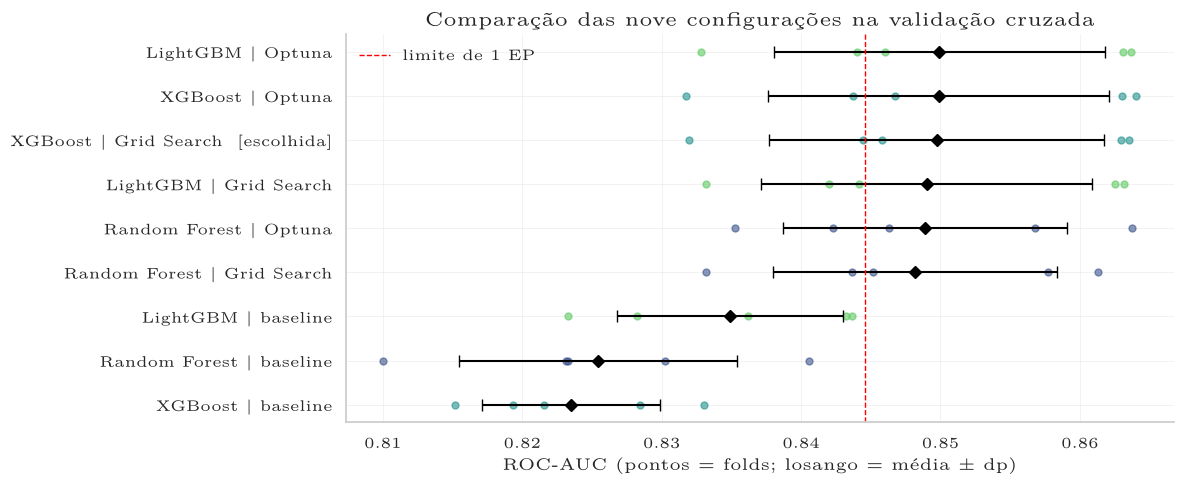

In [32]:
# Dispersão dos folds das nove configurações
fig, ax = plt.subplots(figsize=(12, 5))
ordem = tabela_final.sort_values("AUC CV média").index
for i, rotulo in enumerate(ordem):
    nome = configuracoes[rotulo][0]
    ax.scatter(folds_finais[rotulo], [i] * K, color=CORES[nome], s=25, alpha=0.6)
    ax.errorbar(tabela_final.loc[rotulo, "AUC CV média"], i, xerr=tabela_final.loc[rotulo, "AUC CV desvio"],
                fmt="D", color="black", capsize=4)
ax.axvline(limite, ls="--", color="red", lw=1, label="limite de 1 EP")
ax.set_yticks(range(len(ordem)), [r + ("  [escolhida]" if r == CONFIG_ESCOLHIDA else "") for r in ordem])
ax.set_xlabel("ROC-AUC (pontos = folds; losango = média ± dp)")
ax.set_title("Comparação das nove configurações na validação cruzada")
ax.legend()
plt.tight_layout()
plt.show()

**Justificativa da escolha.**

- A maior AUC CV é a do **LightGBM | Optuna (0,8499)**, com erro-padrão de 0,0053. Seis configurações (todas as versões ajustadas) ficam acima do limite de 0,8446 — ou seja, **são estatisticamente indistinguíveis**; os três baselines ficam claramente abaixo.
- Entre as seis, o **XGBoost | Grid Search** tem o **menor gap** treino–validação (0,014, contra 0,019–0,048 das demais), AUC CV de 0,8497 (apenas 0,0002 abaixo da melhor), a melhor PR-AUC (0,669, empatado com XGBoost | Optuna), o melhor F1 no limiar 0,5 e o **menor custo de ajuste** (≈0,12 s por fold).
- Além disso, é o modelo **mais simples** entre os candidatos: 200 árvores de profundidade 2 (cada árvore modela, no máximo, interações de segunda ordem), com apenas 4 hiperparâmetros definidos em valores "redondos" de uma grade — menos sujeito a ter sido ajustado ao acaso dos folds do que as soluções contínuas do Optuna.

**Configuração promovida ao teste final: `XGBoost | Grid Search`** — `n_estimators=200`, `max_depth=2`, `learning_rate=0,05`, `subsample=0,8`.

#### 6.2 Overfitting e underfitting

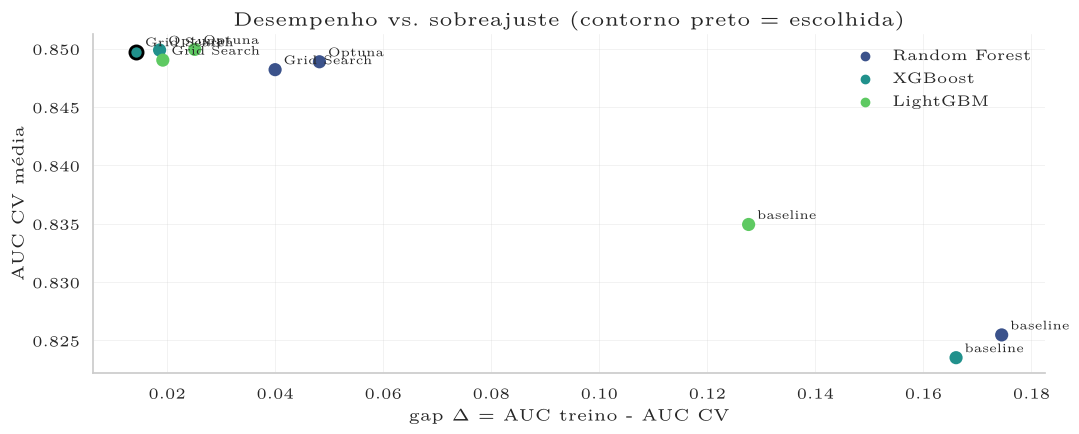

In [33]:
# 6.2 Gap treino-validação das nove configurações
fig, ax = plt.subplots(figsize=(11, 4.5))
for rotulo in tabela_final.index:
    nome = configuracoes[rotulo][0]
    t = tabela_final.loc[rotulo]
    ax.scatter(t["gap (treino - CV)"], t["AUC CV média"], color=CORES[nome], s=90,
               edgecolor="black" if rotulo == CONFIG_ESCOLHIDA else "none", linewidth=2)
    ax.annotate(rotulo.split(" | ")[1], (t["gap (treino - CV)"], t["AUC CV média"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
for nome, cor in CORES.items():
    ax.scatter([], [], color=cor, label=nome)
ax.set_xlabel("gap Δ = AUC treino - AUC CV")
ax.set_ylabel("AUC CV média")
ax.set_title("Desempenho vs. sobreajuste (contorno preto = escolhida)")
ax.legend()
plt.tight_layout()
plt.show()

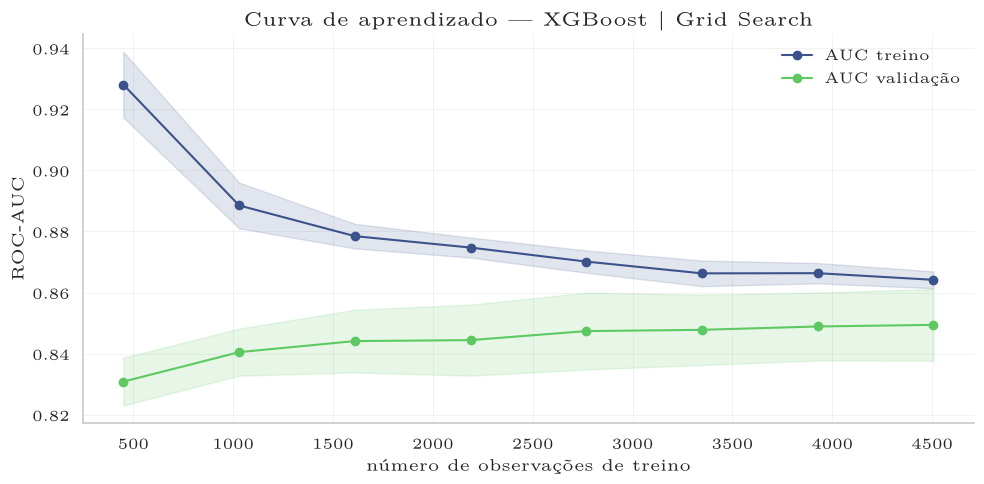

,n treino,AUC treino,dp treino,AUC validação,dp validação,gap
0,450,0.9281,0.0108,0.8308,0.0078,0.0973
1,1030,0.8885,0.0075,0.8405,0.0077,0.0480
2,1609,0.8785,0.0040,0.8441,0.0103,0.0344
3,2189,0.8747,0.0033,0.8444,0.0116,0.0303
4,2768,0.8701,0.0037,0.8474,0.0126,0.0228
5,3348,0.8663,0.0042,0.8478,0.0115,0.0185
6,3927,0.8663,0.0033,0.8489,0.0111,0.0174
7,4507,0.8642,0.0028,0.8494,0.0117,0.0147


In [34]:
# Curva de aprendizado da configuração escolhida (mesmos folds, ROC-AUC)
pipeline_escolhido = criar_pipeline(construtores[MODELO_ESCOLHIDO](**PARAMS_ESCOLHIDOS))
tamanhos, sc_treino, sc_val = learning_curve(
    pipeline_escolhido, X_treino, y_treino, cv=cv, scoring=METRICA_PRINCIPAL,
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=N_JOBS, shuffle=True, random_state=RANDOM_STATE,
)
curva = pd.DataFrame({"n treino": tamanhos,
                      "AUC treino": sc_treino.mean(1), "dp treino": sc_treino.std(1),
                      "AUC validação": sc_val.mean(1), "dp validação": sc_val.std(1)})
curva["gap"] = curva["AUC treino"] - curva["AUC validação"]

fig, ax = plt.subplots(figsize=(10, 5))
for col, dp, cor in [("AUC treino", "dp treino", "#3b528b"), ("AUC validação", "dp validação", "#5ec962")]:
    ax.plot(curva["n treino"], curva[col], "o-", color=cor, label=col)
    ax.fill_between(curva["n treino"], curva[col] - curva[dp], curva[col] + curva[dp], color=cor, alpha=0.15)
ax.set_xlabel("número de observações de treino")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Curva de aprendizado — {CONFIG_ESCOLHIDA}")
ax.legend()
plt.tight_layout()
plt.show()
display(curva)

**Análise de overfitting e underfitting.**

- **Gap das nove configurações:** os baselines ficam no canto de alto gap (0,13–0,17) e baixa AUC — sobreajuste claro. O tuning deslocou todos os modelos para gaps de 0,014–0,048 com AUC maior. No Random Forest o gap continua maior (≈0,04–0,05), característica esperada do *bagging*, cujas árvores individuais são profundas.
- **Curva de aprendizado do modelo escolhido:** a AUC de treino **desce** de 0,928 (450 observações) para 0,864, enquanto a AUC de validação **sobe** de 0,831 para 0,849, e o gap encolhe de 0,097 para **0,015**. As curvas convergem para um patamar próximo, comportamento típico de **boa generalização**.
- **Sem underfitting relevante:** a AUC de treino com todos os dados (0,864) não é muito superior à de validação; um modelo subajustado mostraria ambas baixas e próximas desde o início. Aqui ambas são altas, e o modelo de profundidade 2 captura as interações principais (contrato × permanência).
- **Mais dados ajudariam pouco:** a curva de validação ainda sobe levemente no final (+0,0005 entre os dois últimos pontos), mas está quase estável; o ganho marginal de mais observações seria pequeno. A faixa de ±1 dp entre folds (≈0,012) é maior que essa variação, indicando que a incerteza amostral domina.

#### 6.3 Interpretação do comportamento do modelo

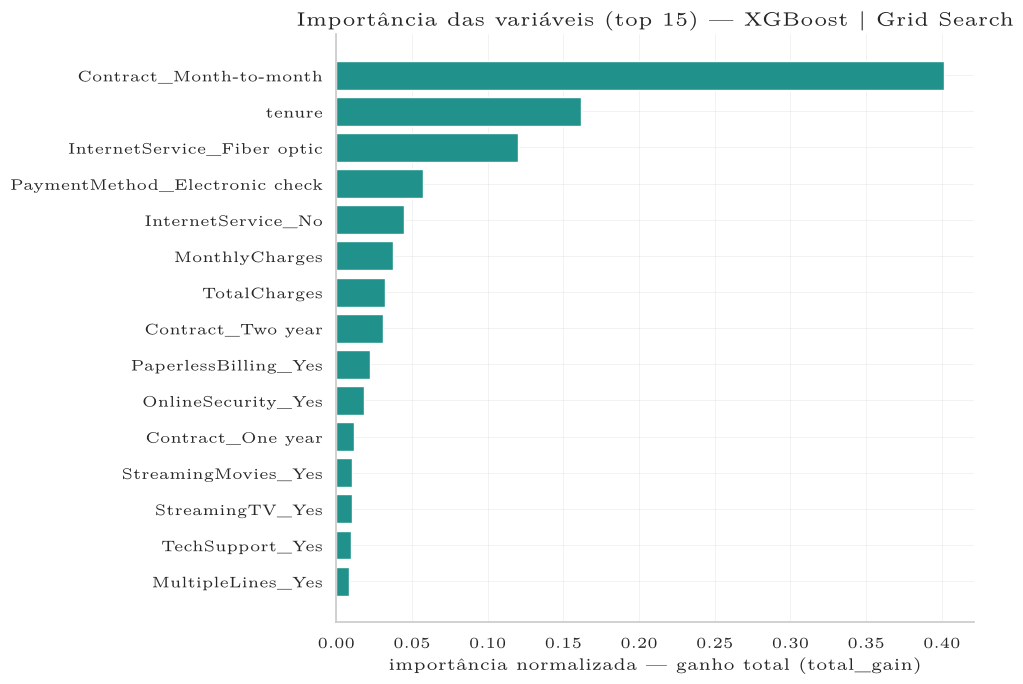

,importância agregada
Contract,0.4435
InternetService,0.1650
tenure,0.1615
PaymentMethod,0.0586
MonthlyCharges,0.0378
TotalCharges,0.0319
PaperlessBilling,0.0225
OnlineSecurity,0.0186
StreamingMovies,0.0106
StreamingTV,0.0105


In [35]:
# 6.3 Importância das variáveis do modelo escolhido (ajustado apenas em D_treino)
pipeline_escolhido.fit(X_treino, y_treino)
nomes_features = pipeline_escolhido.named_steps["preprocessamento"].get_feature_names_out()
estimador = pipeline_escolhido.named_steps["modelo"]

if MODELO_ESCOLHIDO == "LightGBM":
    importancias = estimador.booster_.feature_importance(importance_type="gain")
    tipo_imp = "ganho total (gain)"
elif MODELO_ESCOLHIDO == "XGBoost":
    ganho = estimador.get_booster().get_score(importance_type="total_gain")
    importancias = np.array([ganho.get(f"f{i}", 0.0) for i in range(len(nomes_features))])
    tipo_imp = "ganho total (total_gain)"
else:
    importancias = estimador.feature_importances_
    tipo_imp = "redução média de impureza"

imp = pd.Series(importancias / importancias.sum(), index=nomes_features).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
top = imp.tail(15)
ax.barh(top.index, top.values, color=CORES[MODELO_ESCOLHIDO])
ax.set_xlabel(f"importância normalizada — {tipo_imp}")
ax.set_title(f"Importância das variáveis (top 15) — {CONFIG_ESCOLHIDA}")
plt.tight_layout()
plt.show()

# agregação por variável original (soma das dummies)
original = {f: next(v for v in sorted(VARIAVEIS_MODELO, key=len, reverse=True) if f.startswith(v))
            for f in nomes_features}
imp_original = imp.groupby(original).sum().sort_values(ascending=False)
display(imp_original.rename("importância agregada").to_frame().head(10))

AUC out-of-fold: 0.8492
Limiar escolhido (máx. F1 OOF): 0.34 | F1 = 0.6386 (F1 com 0,5 = 0.5967)


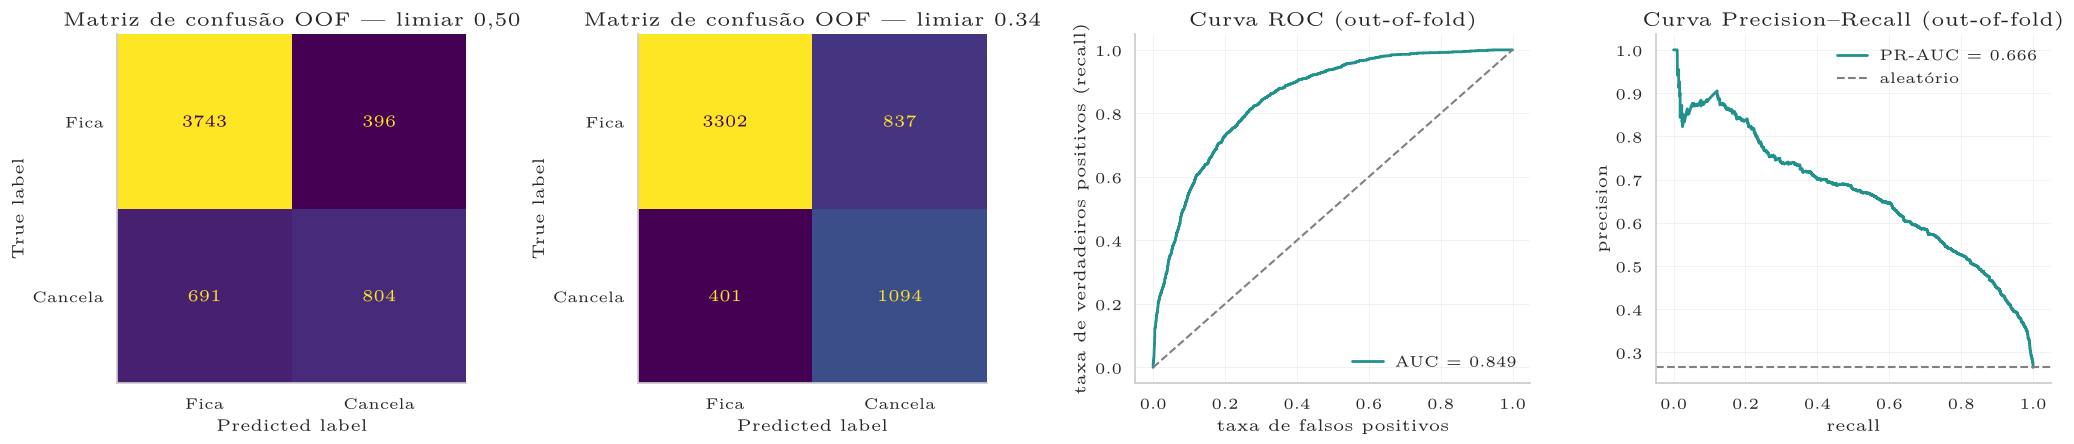

In [36]:
# Previsões out-of-fold (somente D_treino) para curvas e escolha do limiar
proba_oof = cross_val_predict(pipeline_escolhido, X_treino, y_treino, cv=cv,
                              method="predict_proba", n_jobs=N_JOBS)[:, 1]

# limiar que maximiza o F1 nas previsões out-of-fold (o teste não participa)
limiares = np.round(np.arange(0.10, 0.71, 0.01), 2)
f1_por_limiar = np.array([f1_score(y_treino, (proba_oof >= t).astype(int)) for t in limiares])
LIMIAR = float(limiares[f1_por_limiar.argmax()])
print(f"AUC out-of-fold: {roc_auc_score(y_treino, proba_oof):.4f}")
print(f"Limiar escolhido (máx. F1 OOF): {LIMIAR:.2f} | F1 = {f1_por_limiar.max():.4f} "
      f"(F1 com 0,5 = {f1_score(y_treino, (proba_oof >= 0.5).astype(int)):.4f})")

fig, axes = plt.subplots(1, 4, figsize=(21, 4.6))
for ax, t, titulo in [(axes[0], 0.5, "limiar 0,50"), (axes[1], LIMIAR, f"limiar {LIMIAR:.2f}")]:
    ConfusionMatrixDisplay(confusion_matrix(y_treino, (proba_oof >= t).astype(int)),
                           display_labels=["Fica", "Cancela"]).plot(ax=ax, cmap="viridis", colorbar=False)
    ax.set_title(f"Matriz de confusão OOF — {titulo}")
    ax.grid(False)

fpr, tpr, _ = roc_curve(y_treino, proba_oof)
axes[2].plot(fpr, tpr, color=CORES[MODELO_ESCOLHIDO], lw=2,
             label=f"AUC = {roc_auc_score(y_treino, proba_oof):.3f}")
axes[2].plot([0, 1], [0, 1], ls="--", color="gray")
axes[2].set_xlabel("taxa de falsos positivos")
axes[2].set_ylabel("taxa de verdadeiros positivos (recall)")
axes[2].set_title("Curva ROC (out-of-fold)")
axes[2].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_treino, proba_oof)
axes[3].plot(rec, prec, color=CORES[MODELO_ESCOLHIDO], lw=2,
             label=f"PR-AUC = {average_precision_score(y_treino, proba_oof):.3f}")
axes[3].axhline(y_treino.mean(), ls="--", color="gray", label="aleatório")
axes[3].set_xlabel("recall")
axes[3].set_ylabel("precision")
axes[3].set_title("Curva Precision–Recall (out-of-fold)")
axes[3].legend()
plt.tight_layout()
plt.show()

**Interpretação do comportamento do modelo.**

- **Importância das variáveis:** agregando as *dummies*, **`Contract` responde por ≈44% do ganho total**, seguido de **`InternetService` (≈17%)** e **`tenure` (≈16%)**; `PaymentMethod`, `MonthlyCharges` e `TotalCharges` vêm em seguida. É exatamente a hierarquia sugerida pela EDA: contrato mensal, fibra óptica, pouco tempo de casa e boleto eletrônico elevam o risco. As variáveis demográficas (gênero, parceiro) quase não contribuem. A coerência entre EDA e modelo é uma evidência de que ele aprendeu padrões reais, e não artefatos.
- **Curvas ROC e Precision–Recall (out-of-fold, apenas $\mathcal{D}_{\mathrm{treino}}$):** AUC = 0,849 e PR-AUC = 0,666 (2,5× a referência aleatória). A curva PR mostra que é possível ter precisão de ≈0,75 com recall de ≈0,3, ou seja, o topo da lista de risco é bastante confiável para uma campanha pequena.
- **Limiar de decisão:** com o limiar padrão 0,5, o modelo captura apenas 54% dos churners (804 de 1.495). Como a classe é minoritária e o custo de perder um cliente é maior que o de oferecer um desconto, o limiar foi escolhido **maximizando o F1 nas previsões out-of-fold**, sem usar o teste: **t = 0,34**. Com ele o recall sobe para 73% (1.094 churners identificados) e a precisão fica em 57%, elevando o F1 de 0,597 para 0,639. Esse limiar é salvo junto com o modelo e usado pela aplicação Streamlit.

<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>


**Resposta do aluno — Exercício 7**

A configuração escolhida no Exercício 6 é reajustada em todo $\mathcal{D}_{\mathrm{treino}}$ e avaliada **uma única vez** em $\mathcal{D}_{\mathrm{teste}}$. O limiar de decisão é o definido na validação cruzada (não é recalibrado no teste).

#### 7.1 Avaliação final no conjunto de teste

In [37]:
# Resposta do aluno - exercício 7
# 7.1 Reajuste em todo D_treino e avaliação única em D_teste
modelo_final = criar_pipeline(construtores[MODELO_ESCOLHIDO](**PARAMS_ESCOLHIDOS))
modelo_final.fit(X_treino, y_treino)

proba_teste = modelo_final.predict_proba(X_teste)[:, 1]
pred_teste = (proba_teste >= LIMIAR).astype(int)
pred_teste_05 = (proba_teste >= 0.5).astype(int)

def metricas(y_true, proba, pred):
    return {"ROC-AUC": roc_auc_score(y_true, proba), "PR-AUC": average_precision_score(y_true, proba),
            "F1": f1_score(y_true, pred), "recall": recall_score(y_true, pred),
            "precision": precision_score(y_true, pred), "acurácia": accuracy_score(y_true, pred)}

linha_cv = tabela_final.loc[CONFIG_ESCOLHIDA]
comparacao = pd.DataFrame({
    "CV (média ± dp)": [f"{linha_cv['AUC CV média']:.4f} ± {linha_cv['AUC CV desvio']:.4f}",
                        f"{linha_cv['PR-AUC CV']:.4f}", None, None, None, f"{linha_cv['acurácia CV']:.4f}"],
    "OOF treino (limiar escolhido)": list(metricas(y_treino, proba_oof, (proba_oof >= LIMIAR).astype(int)).values()),
    f"TESTE (limiar {LIMIAR:.2f})": list(metricas(y_teste, proba_teste, pred_teste).values()),
    "TESTE (limiar 0,50)": list(metricas(y_teste, proba_teste, pred_teste_05).values()),
}, index=["ROC-AUC", "PR-AUC", "F1", "recall", "precision", "acurácia"])
display(comparacao)

# intervalo de confiança bootstrap (95%) para a AUC de teste
rng = np.random.default_rng(RANDOM_STATE)
yt, pt = y_teste.to_numpy(), proba_teste
aucs_boot = []
for _ in range(1000):
    i = rng.integers(0, len(yt), len(yt))
    if yt[i].min() != yt[i].max():
        aucs_boot.append(roc_auc_score(yt[i], pt[i]))
ic = np.percentile(aucs_boot, [2.5, 97.5])
auc_teste = roc_auc_score(y_teste, proba_teste)
print(f"AUC teste = {auc_teste:.4f} | IC95% bootstrap = [{ic[0]:.4f}; {ic[1]:.4f}]")
print(f"AUC CV    = {linha_cv['AUC CV média']:.4f} | faixa dos folds = "
      f"[{folds_finais[CONFIG_ESCOLHIDA].min():.4f}; {folds_finais[CONFIG_ESCOLHIDA].max():.4f}]")

,CV (média ± dp),OOF treino (limiar escolhido),TESTE (limiar 0.34),"TESTE (limiar 0,50)"
ROC-AUC,0.8497 ± 0.0120,0.8492,0.8469,0.8469
PR-AUC,0.6687,0.6657,0.6645,0.6645
F1,NaN,0.6386,0.6342,0.5830
recall,NaN,0.7318,0.7487,0.5214
precision,NaN,0.5665,0.5501,0.6610
acurácia,0.8071,0.7803,0.7708,0.8020


AUC teste = 0.8469 | IC95% bootstrap = [0.8251; 0.8673]
AUC CV    = 0.8497 | faixa dos folds = [0.8319; 0.8635]


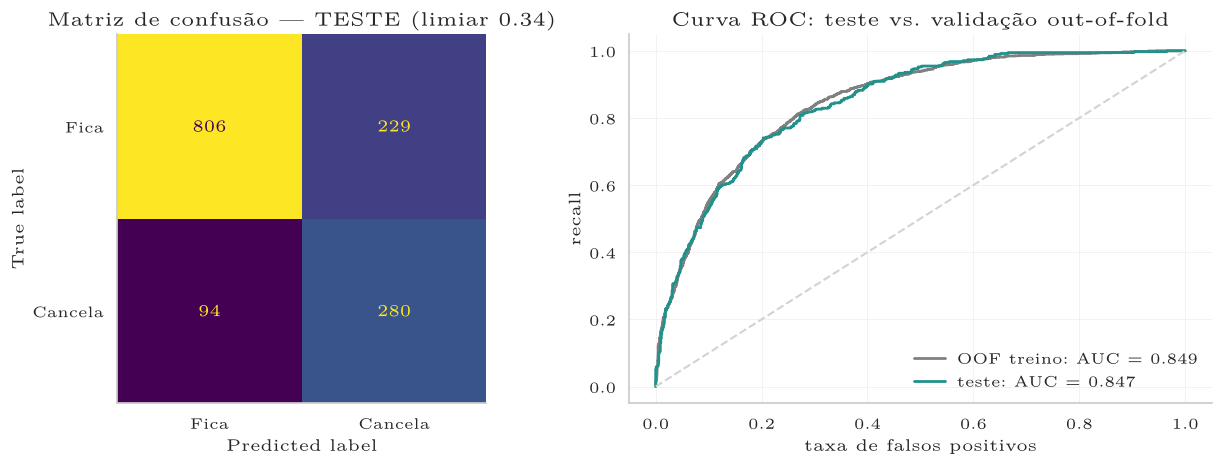

In [38]:
# Gráficos do teste: matriz de confusão e ROC teste vs. OOF
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ConfusionMatrixDisplay(confusion_matrix(y_teste, pred_teste), display_labels=["Fica", "Cancela"]).plot(
    ax=axes[0], cmap="viridis", colorbar=False)
axes[0].set_title(f"Matriz de confusão — TESTE (limiar {LIMIAR:.2f})")
axes[0].grid(False)
for yy, pp, rot, cor in [(y_treino, proba_oof, "OOF treino", "gray"), (y_teste, proba_teste, "teste", CORES[MODELO_ESCOLHIDO])]:
    f, t, _ = roc_curve(yy, pp)
    axes[1].plot(f, t, lw=2, color=cor, label=f"{rot}: AUC = {roc_auc_score(yy, pp):.3f}")
axes[1].plot([0, 1], [0, 1], ls="--", color="lightgray")
axes[1].set_xlabel("taxa de falsos positivos")
axes[1].set_ylabel("recall")
axes[1].set_title("Curva ROC: teste vs. validação out-of-fold")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

**Discussão da avaliação final.**

- **Métrica principal:** AUC de teste = **0,847** (IC 95% bootstrap: 0,825–0,867), contra **0,850 ± 0,012** na validação cruzada. A diferença (−0,003) é menor que um quarto do desvio entre folds, e o valor de teste está dentro da faixa observada nos folds (0,832–0,864). **O desempenho é compatível com o estimado durante o desenvolvimento** — não houve otimismo da validação cruzada nem vazamento.
- **Métricas auxiliares:** PR-AUC de 0,665 (CV: 0,669). Com o limiar 0,34 definido na validação, o modelo identifica **75% dos clientes que cancelaram** (recall), com precisão de 55% e F1 de 0,634 — praticamente o mesmo F1 obtido nas previsões out-of-fold (0,639), o que confirma que o limiar escolhido no treino se transfere bem para dados novos.
- **Efeito do limiar:** com 0,5 a acurácia seria maior (0,802 vs. 0,771), mas o recall cairia para 52%. A acurácia é enganosa aqui: o modelo trivial já teria 0,735. Para o objetivo de retenção, perder metade dos churners é pior do que abordar alguns clientes que não cancelariam.
- **Generalização:** curva de aprendizado com gap final de 0,015, variabilidade pequena entre folds e resultado de teste dentro do intervalo esperado formam um conjunto consistente de evidências de que o modelo generaliza bem para clientes não vistos.

#### 7.2 Teste de consistência

In [39]:
# 7.2 Seis observações do TESTE (não participaram do treinamento)
teste_df = df.loc[X_teste.index].copy()
teste_df["y"] = y_teste
teste_df["prob_churn"] = proba_teste
teste_df["y_hat"] = pred_teste

def escolher(mascara, coluna, maior=True):
    sub = teste_df[mascara].sort_values(coluna, ascending=not maior)
    return sub.index[0]

casos = {
    "acerto confiante (cancela)": escolher((teste_df.y == 1) & (teste_df.y_hat == 1), "prob_churn", True),
    "acerto confiante (fica)": escolher((teste_df.y == 0) & (teste_df.y_hat == 0), "prob_churn", False),
    "caso limítrofe": (teste_df["prob_churn"] - LIMIAR).abs().idxmin(),
    "acerto típico (fica)": teste_df[(teste_df.y == 0) & (teste_df.y_hat == 0)]
                            .sample(1, random_state=RANDOM_STATE).index[0],
    "difícil: falso negativo": escolher((teste_df.y == 1) & (teste_df.y_hat == 0), "prob_churn", False),
    "difícil: falso positivo": escolher((teste_df.y == 0) & (teste_df.y_hat == 1), "prob_churn", True),
}
colunas_caso = ["customerID", "tenure", "Contract", "MonthlyCharges", "TotalCharges", "InternetService",
                "TechSupport", "OnlineSecurity", "PaymentMethod", "y", "y_hat", "prob_churn"]
tabela_casos = teste_df.loc[list(casos.values()), colunas_caso].copy()
tabela_casos.insert(0, "caso", list(casos.keys()))
tabela_casos["acertou?"] = np.where(tabela_casos["y"] == tabela_casos["y_hat"], "sim", "não")
display(tabela_casos.reset_index(drop=True))

,caso,customerID,tenure,Contract,MonthlyCharges,TotalCharges,InternetService,TechSupport,OnlineSecurity,PaymentMethod,y,y_hat,prob_churn,acertou?
0,acerto confiante (cancela),5178-LMXOP,1,Month-to-month,95.1000,95.1000,Fiber optic,No,No,Electronic check,1,1,0.9063,sim
1,acerto confiante (fica),1166-PQLGG,72,Two year,19.5500,"1,463.4500",No,No,No,Bank transfer (automatic),0,0,0.0054,sim
2,caso limítrofe,8805-JNRAZ,2,Month-to-month,49.2000,103.7000,DSL,No,No,Mailed check,0,0,0.3399,sim
3,acerto típico (fica),9135-HSWOC,64,Two year,19.7000,"1,274.0500",No,No,No,Bank transfer (automatic),0,0,0.0112,sim
4,difícil: falso negativo,8580-QVLOC,72,Two year,92.4500,"6,440.2500",DSL,Yes,Yes,Credit card (automatic),1,0,0.0093,não
5,difícil: falso positivo,1628-BIZYP,1,Month-to-month,85.0000,85.0000,Fiber optic,No,No,Electronic check,0,1,0.8262,não


**Interpretação dos casos.**

- **Acerto confiante — cancela (p = 0,91):** 1 mês de casa, contrato mensal, fibra óptica a US\$ 95, sem suporte nem segurança, pagamento por boleto eletrônico. Reúne todos os fatores de risco identificados na EDA; o modelo acerta com alta confiança.
- **Acerto confiante — fica (p = 0,005):** 72 meses de casa, contrato de 2 anos, sem internet, débito automático. É o perfil oposto: cliente antigo, preso a contrato longo e com mensalidade baixa (US\$ 19,55).
- **Acerto típico — fica (p = 0,011):** perfil semelhante (64 meses, contrato bienal, sem internet), confirmando a regularidade do padrão aprendido.
- **Caso limítrofe (p = 0,340, limiar 0,34):** 2 meses de casa e contrato mensal (fatores de risco), mas internet DSL, mensalidade moderada (US\$ 49) e boleto pelo correio (fatores protetores). O modelo fica literalmente na fronteira e classifica como "fica" — o que estava correto, mas mostra que, para esses casos, a probabilidade é mais informativa do que a classe.
- **Caso difícil — falso negativo (p = 0,009):** cliente com 72 meses, contrato de 2 anos, DSL com suporte técnico e segurança, pagamento automático no cartão — todos os sinais de fidelidade. Mesmo assim cancelou. A causa provável está **fora das variáveis disponíveis** (mudança de endereço, oferta da concorrência, insatisfação não registrada); nenhum modelo baseado nesses atributos o anteciparia, e ele é coerente com o padrão aprendido.
- **Caso difícil — falso positivo (p = 0,83):** 1 mês, contrato mensal, fibra, boleto eletrônico, sem serviços adicionais — perfil de altíssimo risco que não cancelou **no mês observado**. Como o alvo mede apenas o último mês, é plausível que parte desses "falsos positivos" sejam clientes em risco real; para o negócio, abordá-los com uma oferta de retenção é um custo aceitável.

Em todos os casos, a direção das probabilidades acompanha os fatores mais importantes do modelo (contrato, permanência, internet e forma de pagamento); os erros ocorrem em perfis atípicos para sua classe, e não por comportamento incoerente do modelo.

#### 7.3 Artefato final, teste de paridade, GitHub e Streamlit

In [40]:
# 7.3 Salvamento do artefato usado pela aplicação Streamlit
Path("models").mkdir(exist_ok=True)
artefato = {
    "pipeline": modelo_final,
    "limiar": LIMIAR,
    "configuracao": CONFIG_ESCOLHIDA,
    "parametros": {k: v for k, v in PARAMS_ESCOLHIDOS.items() if v is not None},
    "variaveis": VARIAVEIS_MODELO,
    "metricas_cv": {"roc_auc_media": float(linha_cv["AUC CV média"]),
                    "roc_auc_desvio": float(linha_cv["AUC CV desvio"])},
    "metricas_teste": {k: float(v) for k, v in metricas(y_teste, proba_teste, pred_teste).items()},
    "taxa_churn_treino": float(y_treino.mean()),
    "versoes": {"scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__,
                "lightgbm": lightgbm.__version__},
}
joblib.dump(artefato, "models/modelo_final.joblib", compress=3)

# casos de paridade: entradas BRUTAS (formato original da base) + previsão do notebook
casos_paridade = df_bruto.loc[list(casos.values()), [IDENTIFICADOR] + VARIAVEIS_MODELO].copy()
casos_paridade.insert(0, "caso", list(casos.keys()))
casos_paridade["prob_churn_notebook"] = proba_teste[[X_teste.index.get_loc(i) for i in casos.values()]]
casos_paridade.to_csv("models/casos_paridade.csv", index=False)

with open("models/metadados.json", "w", encoding="utf-8") as f:
    json.dump({k: v for k, v in artefato.items() if k != "pipeline"}, f, ensure_ascii=False, indent=2, default=str)

print("Arquivos salvos:", sorted(p.name for p in Path("models").iterdir()))
print(f"Tamanho do artefato: {Path('models/modelo_final.joblib').stat().st_size / 1024:.0f} KB")

Arquivos salvos: ['casos_paridade.csv', 'metadados.json', 'modelo_final.joblib']
Tamanho do artefato: 28 KB


In [41]:
# Teste de paridade: artefato recarregado do disco + função prever() da aplicação Streamlit
artefato_disco = carregar_artefato("models/modelo_final.joblib")
entradas_app = pd.read_csv("models/casos_paridade.csv")   # entradas brutas, como digitadas na interface
saida_app = prever(entradas_app[VARIAVEIS_MODELO], artefato_disco)

paridade = pd.DataFrame({
    "caso": entradas_app["caso"],
    "prob notebook": entradas_app["prob_churn_notebook"],
    "prob app (prever)": saida_app["prob_churn"],
    "classe app": saida_app["churn_previsto"],
})
paridade["diferença absoluta"] = (paridade["prob notebook"] - paridade["prob app (prever)"]).abs()
display(paridade)
assert np.allclose(paridade["prob notebook"], paridade["prob app (prever)"], atol=1e-9), "Divergência!"
print("Paridade confirmada: notebook e função de inferência da aplicação produzem a mesma probabilidade.")

,caso,prob notebook,prob app (prever),classe app,diferença absoluta
0,acerto confiante (cancela),0.9063,0.9063,1,0.0000
1,acerto confiante (fica),0.0054,0.0054,0,0.0000
2,caso limítrofe,0.3399,0.3399,0,0.0000
3,acerto típico (fica),0.0112,0.0112,0,0.0000
4,difícil: falso negativo,0.0093,0.0093,0,0.0000
5,difícil: falso positivo,0.8262,0.8262,1,0.0000


Paridade confirmada: notebook e função de inferência da aplicação produzem a mesma probabilidade.


**GitHub e Streamlit.** O repositório segue a estrutura abaixo; a aplicação (`app.py`) importa **a mesma função de limpeza** (`src/preparacao.py`) e **a mesma função de inferência** (`src/inferencia.py`) usadas no teste de paridade acima, e carrega o artefato `models/modelo_final.joblib` gerado por este notebook (pipeline completo: pré-processamento + XGBoost + limiar).

```
cp5-churn-telco/
├── Checkpoint05_RF_XGBoost_LightGBM.ipynb   # este notebook
├── app.py                                   # aplicação Streamlit
├── src/preparacao.py                        # limpeza determinística + pipeline
├── src/inferencia.py                        # carregamento do artefato e previsão
├── models/modelo_final.joblib               # pipeline final treinado
├── models/metadados.json                    # parâmetros, limiar e métricas
├── models/casos_paridade.csv                # casos do teste de paridade
├── data/Telco-Customer-Churn.csv            # base (licença Apache 2.0)
├── requirements.txt
└── README.md
```

**Teste de paridade na interface:** a aplicação tem um botão para carregar qualquer um dos seis casos de `models/casos_paridade.csv` no formulário; a probabilidade exibida deve coincidir com a coluna `prob notebook` da tabela acima (por exemplo, **90,63%** para o caso "acerto confiante (cancela)", cliente `5178-LMXOP`).

In [42]:
# Links finais da entrega
URL_GITHUB = "https://github.com/<usuario>/cp5-churn-telco"         # substituir após publicar
URL_STREAMLIT = "https://<app>.streamlit.app"                        # substituir após o deploy

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

GitHub: https://github.com/<usuario>/cp5-churn-telco
Streamlit: https://<app>.streamlit.app


#### 7.4 Síntese para a apresentação oral (≤ 10 minutos)

| Tempo | Bloco | Mensagem principal | Evidência a mostrar |
|---|---|---|---|
| 0:00–1:00 | Problema | Prever churn para priorizar retenção; classificação binária; 7.043 clientes, 26,5% de churn | Gráfico da distribuição do alvo |
| 1:00–2:30 | Dados e wrangling | `TotalCharges` texto com 11 brancos = clientes novos → 0; categorias redundantes recodificadas; nada removido; `customerID` excluído por vazamento | Tabela de decisões (2.2) |
| 2:30–3:30 | EDA | Contrato mensal, poucos meses de casa, fibra e boleto eletrônico concentram o churn (55% no mensal com ≤ 6 meses) | Heatmap contrato × tenure |
| 3:30–4:00 | Protocolo | 80/20 estratificado, mesmos 5 folds para tudo, ROC-AUC como métrica principal, teste isolado até o fim | Tabela de folds |
| 4:00–5:00 | Baselines | Os três sobreajustam (gap 0,13–0,17); LightGBM é o melhor baseline | Gráfico treino vs. validação |
| 5:00–6:30 | Tuning | Grid e Optuna convergem para ≈0,850; ganhos do Optuna < 0,001 (dentro do ruído); busca do Optuna mais eficiente | Histórico do Optuna + tabela 5.3 |
| 6:30–7:30 | Escolha e overfitting | Regra de 1 erro-padrão + menor gap → XGBoost Grid (profundidade 2); curva de aprendizado converge (gap 0,015) | Gráfico das nove configurações + curva de aprendizado |
| 7:30–8:30 | Teste final | AUC teste 0,847 vs. CV 0,850; recall 75% com limiar 0,34; casos de consistência | Tabela CV × teste |
| 8:30–10:00 | Demo | Formulário do Streamlit + paridade com o caso `5178-LMXOP` (90,63%) | Aplicação ao vivo |

**Divisão sugerida:** cada integrante apresenta dois blocos consecutivos; todos devem dominar a regra de seleção do modelo, o motivo do limiar 0,34 e por que o teste não foi usado antes do Exercício 7.

<br>

---

<br>

# **Referências**

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.

<br>

---

<br>

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).